In [6]:
# === SETUP: Run this first! ===
import os
import sys

# Change to project root and add to Python path
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)  # Goes up one level from 'notebooks/'
os.chdir(project_root)
sys.path.insert(0, project_root)

print(f"Project root: {project_root}")
print(f"tsnn module path: {os.path.join(project_root, 'tsnn')}")

Project root: /Users/gremy/Code/TSNN-1
tsnn module path: /Users/gremy/Code/TSNN-1/tsnn


In [7]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, RidgeCV, LinearRegression
import torch
from torch.utils.data import Dataset, random_split
from torch.utils.data import DataLoader
import importlib
import sys
from tqdm import tqdm
#sys.path.append('/Users/cyrilgarcia/notebooks/tsnn/')

import tsnn

from tsnn.generators import generators
from tsnn.benchmarks import benchmark_comparison, ml_benchmarks, torch_benchmarks
from tsnn import utils
import torch.nn.functional as F
import math
from typing import Optional
from tsnn.tstorch import transformers
from sklearn.linear_model import LinearRegression, ElasticNetCV, ElasticNet




plt.style.use('ggplot')

In [8]:
from dataclasses import dataclass
from torch import nn


In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")

Using device: mps


In [10]:
from typing import Dict

In [11]:
from tsnn.tstorch import models

In [12]:
from tsnn.tstorch.models import GlobalMLP, BiDimensionalMLP, OneDimensionalTransformer, CustomBiDimensionalTransformer
from sklearn.ensemble import HistGradientBoostingRegressor

# Summary

In [13]:
# In this notebook we will run the experiments to generate the figures for the paper.

# Test dataset

In [14]:
# We work with the following data.

In [15]:
# Global parameters
T_max = 5000
N1 = 10
F1 = 20
T1 = 5 # This parameter will be the n_rolling

print(T_max, N1, F1, T1)

5000 10 20 5


In [16]:
def generate_synthetic_datasets(
    num_time_steps: int = 3000,
    num_time_series: int = 10,
    num_features: int = 10,
    low_corr: float = 0.1,
    high_corr: float = 0.2,
    pct_zero_corr: float = 0.5,
) -> Dict[str, "generators.Generator"]:
    """
    Generates 5 synthetic multivariate time series datasets with different
    types of cross-series dependencies.

    Returns
    -------
    dict
        Keys: "d_lin", "d_cond", "d_shift", "d_cs", "d_cs_shift", "d_all"
        Values: generators.Generator objects (already with .train and .test)
    """
    dic_data = {}

    # Helper to avoid repeating the same 10 lines
    def make_gen(split_conditional=0.0,
                 split_shift=0.0,
                 split_seasonal=0.0,
                 split_cs=0.0,
                 split_cs_shift=0.0):
        gen = generators.Generator(num_time_steps, num_time_series, num_features)
        gen.generate_dataset(
            pct_zero_corr=pct_zero_corr,
            split_conditional=split_conditional,
            split_shift=split_shift,
            split_seasonal=split_seasonal,
            split_cs=split_cs,
            split_cs_shift=split_cs_shift,
            low_corr=low_corr,
            high_corr=high_corr,
        )
        return gen

    dic_data["d_lin"] = make_gen()

    # 1. Pure conditional (causal) dependence
    dic_data["d_cond"] = make_gen(split_conditional=1.0)

    # 2. Pure lagged (time-shifted) dependence
    dic_data["d_shift"] = make_gen(split_shift=1.0)

    # 3. Pure contemporaneous cross-sectional correlation
    dic_data["d_cs"] = make_gen(split_cs=1.0)

    # 4. Contemporaneous + lagged cross-series
    dic_data["d_cs_shift"] = make_gen(split_cs_shift=1.0)

    # 5. Equal mix of all four mechanisms
    dic_data["d_all"] = make_gen(
        split_conditional=0.2,
        split_shift=0.2,
        split_cs=0.2,
        split_cs_shift=0.2,
    )

    return dic_data

In [17]:
# list_low_corr = [0.01, 0.025, 0.05, 0.1]
# list_high_corr = [2*x for x in list_low_corr]

list_low_corr = [0.01, 0.03, 0.05, 0.1, 0.3]
list_high_corr = list_low_corr

dic_data = {}

for i in range(len(list_low_corr)):
    name = "correl" + str(list_low_corr[i])
    dic_data[name] = generate_synthetic_datasets(num_time_steps=T_max, num_time_series=N1, num_features=F1, low_corr=list_low_corr[i], high_corr=list_high_corr[i])
    

In [18]:
# We will fix the above dataset for now.

In [19]:
def causal_mask(b, h, q_idx, kv_idx):
    return q_idx >= kv_idx

def build_attention_mask(mask_fn, seq_len, device="cpu"):
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device)
    h = torch.zeros(1, device=device)
    mask_bool = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])  # (seq_len, seq_len)
    return mask_bool

mask = causal_mask
mask = build_attention_mask(mask, T1, device=device)
def custom_mask_mod(b, h, q_idx, kv_idx):
    return mask[q_idx, kv_idx]

# List of models

In [20]:
# Let's list here all the models we wish to test on all the data.

In [21]:
def get_models():
    MLP_global = GlobalMLP(N1, F1, T1, dropout=0.2).to(device)

    MLP_2D = BiDimensionalMLP(N1, F1, T1, dropout=0.2).to(device)

    trans_1D_T4 = OneDimensionalTransformer(N1, F1, T1, mask=mask, attn_direction="T",  num_attn_layers=4,
                                            dropout=0.2, roll_y=True).to(device)
    #Note: using the MLP compression seems very bad..

    trans_2D_TCTC = models.CustomBiDimensionalTransformer(N1, F1, T1, mask=mask, layers='TCTC',
                                                                        dropout=0.05, d_model=128, dim_feedforward=128*4, sparsify=None, 
                                                                               roll_y=True).to(device)

    trans_2D_TCTCTCTC = models.CustomBiDimensionalTransformer(N1, F1, T1, mask=mask, layers='TCTCTCTC',
                                                                        dropout=0.05, d_model=128, dim_feedforward=128*4, sparsify=None, 
                                                                               roll_y=True).to(device)


    dic_models = {'MLP_global':MLP_global, 'MLP_2D':MLP_2D, "trans_1D_T4":trans_1D_T4, "trans_2D_TCTC":trans_2D_TCTC, "trans_2D_TCTCTCTC":trans_2D_TCTCTCTC}

    trans_2D_TCTC_rollfalse = models.CustomBiDimensionalTransformer(N1, F1, T1, mask=mask, layers='TCTC',
                                                                        dropout=0.05, d_model=128, dim_feedforward=128*4, sparsify=None, 
                                                                               roll_y=False).to(device)

    trans_2D_TCTCTCTC_rollfalse = models.CustomBiDimensionalTransformer(N1, F1, T1, mask=mask, layers='TCTCTCTC',
                                                                        dropout=0.05, d_model=128, dim_feedforward=128*4, sparsify=None, 
                                                                               roll_y=False).to(device)


    dic_models_rollfalse = {"trans_2D_TCTC":trans_2D_TCTC_rollfalse, "trans_2D_TCTCTCTC":trans_2D_TCTCTCTC_rollfalse}
    
    return dic_models, dic_models_rollfalse

In [22]:
# For each model we also need to specify the option we will use to fit them.

# Function to create table for an effect

In [37]:
# We give the function that creates for a given effect the table testing all models and all noise level.

In [ ]:
def run_sim(model, n=200, N=N1*T1*F1, T=T_max*0.7, T_OOS=T_max*0.3, rho=0, oos=True):
    res = 0
    for k in tqdm(range(n)):
        
        # constant rho_i case
        rho_i = np.array([rho * np.sqrt(1 / N) for k in range(N)])

        mean = np.zeros(N)
        cov = np.eye(N)
        X = np.random.multivariate_normal(mean=mean, cov=cov, size=T)
        X_OOS = np.random.multivariate_normal(mean=mean, cov=cov, size=T_OOS)
        eps = np.random.normal(size=T)

        y_tilde = np.dot(X, rho_i)
        y_tilde_OOS = np.dot(X_OOS, rho_i)

        y = y_tilde + np.sqrt(1-rho**2)*eps

        model.fit(X, y)
        if oos:
            res += np.corrcoef(model.predict(X_OOS), y_tilde_OOS)[0][1]
        else:
            res += np.corrcoef(model.predict(X), y_tilde)[0][1]
    return res / n

def get_ols_corr(N=N1*T1*F1, T=T_max*0.7, rho=0, oos=True):
    ratio = N/T
    if oos:
        return rho / np.sqrt(rho**2 + (1-rho**2) * ratio/(1-ratio))
    else:
        return rho / np.sqrt(rho**2 + (1-rho**2) * ratio)



def run_models(effect1):

    # Storage
    records_train = []
    records_test  = []

    for noise_level in list(dic_data.keys()):
        
        z = dic_data[noise_level][effect1]
        z.get_dataloader(n_rolling=T1)

        dic_models, dic_models_rollfalse = get_models()


        lasso_full = ml_benchmarks.CustomBenchmarkRolling(LassoCV(alphas=np.linspace(start=1e-4, stop=1e-2, num=30), 
                                                                verbose=False, max_iter=2000, selection='random', n_jobs=5, cv=3))
        lasso_full.fit(z.train)
        boost_model = ml_benchmarks.CustomBenchmarkRolling(HistGradientBoostingRegressor(max_depth=6, max_iter=500, validation_fraction=0.3, n_iter_no_change=100))
        boost_model.fit(z.train)

        comp = benchmark_comparison.Comparator(models=[lasso_full, boost_model], model_names=['lasso_full', 'boosting'])
        corr_train = comp.correl(z, mode="train", return_values=True)
        corr_test  = comp.correl(z, mode="test",  return_values=True)

        # Save results
        records_train.append({
            "noise_level": noise_level,
            "model": 'lasso_full',
            "train_corr_optimal": corr_train.loc['lasso_full', "optimal"]
        })
        records_test.append({
            "noise_level": noise_level,
            "model": 'lasso_full',
            "test_corr_optimal": corr_test.loc['lasso_full', "optimal"]
        })

        records_train.append({
            "noise_level": noise_level,
            "model": 'boosting',
            "train_corr_optimal": corr_train.loc['boosting', "optimal"]
        })
        records_test.append({
            "noise_level": noise_level,
            "model": 'boosting',
            "test_corr_optimal": corr_test.loc['boosting', "optimal"]
        })
        


        for model_key in dic_models.keys():                   
            print(f"Running → {noise_level} | {model_key}")

            z = dic_data[noise_level][effect1]
            if model_key in ["trans_1D_T4", "trans_2D_TCTC", "trans_2D_TCTCTCTC"]:
                z.get_dataloader(n_rolling=T1, roll_y=True)
            else:
                z.get_dataloader(n_rolling=T1)

            if model_key in ["trans_2D_TCTC", "trans_2D_TCTCTCTC"]:
                lr=0.001/2
            else:
                lr=0.001

            epochs = 20
            if noise_level in ['correl0.01', 'correl0.03']:
                epochs = 40

            model = dic_models[model_key]

            # Model
            if noise_level == 'correl0.01' and model_key in ["trans_2D_TCTC", "trans_2D_TCTCTCTC"]:
                z.get_dataloader(n_rolling=T1)
                model = dic_models_rollfalse[model_key]
                epochs = 60
                lr=0.0001

            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            wrapper = torch_benchmarks.TorchWrapper(model, optimizer=optimizer, device=device)

            
            # Train
            wrapper.fit(z.train, test=z.test, epochs=epochs, plot=False)

            # Compare
            comp = benchmark_comparison.Comparator(models=[wrapper], model_names=["model1"])

            corr_train = comp.correl(z, mode="train", return_values=True)
            corr_test  = comp.correl(z, mode="test",  return_values=True)

            train_corr = corr_train.loc["model1", "optimal"]
            test_corr  = corr_test.loc["model1", "optimal"]

            # Save results
            records_train.append({
                "noise_level": noise_level,
                "model": model_key,
                "train_corr_optimal": train_corr
            })
            records_test.append({
                "noise_level": noise_level,
                "model": model_key,
                "test_corr_optimal": test_corr
            })

        records_train.append({
                    "noise_level": noise_level,
                    "model": 'max_linear_corr',
                    # "train_corr_optimal": run_sim(ElasticNetCV(l1_ratio=1, alphas=np.linspace(1e-6, 1e-2, num=50), cv=3), N=N1*F1*T1, 
                    #                               T=T_max, rho=float(noise_level[6:]), oos=False)
                    'train_corr_optimal': get_ols_corr(N=N1*F1*T1, T=T_max*0.7, rho=np.sqrt(0.5*F1*float(noise_level[6:])**2))
                })

        records_test.append({
                    "noise_level": noise_level,
                    "model": 'max_linear_corr',
                    # "test_corr_optimal": run_sim(ElasticNetCV(l1_ratio=1, alphas=np.linspace(1e-6, 1e-2, num=50), cv=3), N=N1*F1*T1, 
                    #                              T=T_max, rho=float(noise_level[6:]), oos=True)
                    'test_corr_optimal': get_ols_corr(N=N1*F1*T1, T=T_max*0.7, rho=np.sqrt(0.5*F1*float(noise_level[6:])**2))
                })
    
    # ————————————————————————————————————————
    # 3. Convert to nice DataFrames
    # ————————————————————————————————————————
    df_train = pd.DataFrame(records_train)
    df_test  = pd.DataFrame(records_test)

    # Pivot: rows = noise level, columns = effect type
    train_pivot = df_train.pivot(index="noise_level", columns="model", values="train_corr_optimal")
    test_pivot  = df_test.pivot(index="noise_level", columns="model", values="test_corr_optimal")

    col_order = ["lasso_full", "boosting"] + list(dic_models.keys()) + ['max_linear_corr']
    train_pivot = train_pivot[col_order]
    test_pivot  = test_pivot[col_order]

    return train_pivot, test_pivot

## Running on linear effect

In [39]:
dic_models, dic_models_rollfalse = get_models()

table_train_lin0, table_test_lin0 = run_models('d_lin')

Running → correl0.01 | MLP_global


100%|██████████| 40/40 [00:06<00:00,  6.07it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | MLP_2D


100%|██████████| 40/40 [00:09<00:00,  4.12it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | trans_1D_T4


...

100%|██████████| 20/20 [00:08<00:00,  2.30it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | trans_2D_TCTC


100%|██████████| 20/20 [00:24<00:00,  1.22s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | trans_2D_TCTCTCTC


100%|██████████| 20/20 [00:44<00:00,  2.24s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [40]:
display(table_train_lin0.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))
display(table_test_lin0.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

noise_level,correl0.01,correl0.03,correl0.05,correl0.1,correl0.3
model,,,,,
lasso_full,0.008,0.024,0.068,0.161,0.300
boosting,0.016,0.021,0.044,0.079,0.188
MLP_global,0.025,0.094,0.153,0.314,0.706
MLP_2D,0.027,0.094,0.162,0.338,0.751
trans_1D_T4,0.029,0.104,0.189,0.379,0.804
trans_2D_TCTC,0.135,0.115,0.580,0.689,0.978
trans_2D_TCTCTCTC,0.073,0.100,0.605,0.631,0.954
max_linear_corr,0.050,0.149,0.245,0.466,0.978


noise_level,correl0.01,correl0.03,correl0.05,correl0.1,correl0.3
model,,,,,
lasso_full,0.010,0.030,0.066,0.122,0.297
boosting,0.004,0.008,0.017,0.035,0.156
MLP_global,0.025,0.119,0.222,0.408,0.812
MLP_2D,0.015,0.065,0.206,0.471,0.860
trans_1D_T4,0.038,0.146,0.279,0.481,0.845
trans_2D_TCTC,0.134,0.121,0.590,0.693,0.978
trans_2D_TCTCTCTC,0.060,0.130,0.609,0.646,0.955
max_linear_corr,0.050,0.149,0.245,0.466,0.978


In [ ]:
# Saving the data

# table_train_lin0.to_csv('table_train_lin.csv', index=True)
# table_test_lin0.to_csv('table_test_lin.csv', index=True)

In [23]:
# Later (even in a new notebook/session)
# table_train_cond = pd.read_csv('my_dataframe.csv', index_col=0)
# table_train_cond.head()

## Running on conditional effect

In [42]:
dic_models, dic_models_rollfalse = get_models()

table_train_cond0, table_test_cond0 = run_models('d_cond')

Running → correl0.01 | MLP_global


100%|██████████| 40/40 [00:06<00:00,  6.01it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | MLP_2D


100%|██████████| 40/40 [00:10<00:00,  3.67it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | trans_1D_T4


...

100%|██████████| 20/20 [00:09<00:00,  2.21it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | trans_2D_TCTC


100%|██████████| 20/20 [00:24<00:00,  1.23s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | trans_2D_TCTCTCTC


100%|██████████| 20/20 [00:45<00:00,  2.28s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [43]:
display(table_train_cond0.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))
display(table_test_cond0.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

noise_level,correl0.01,correl0.03,correl0.05,correl0.1,correl0.3
model,,,,,
lasso_full,0.001,0.022,0.015,0.035,0.084
boosting,0.012,0.030,0.036,0.095,0.181
MLP_global,0.029,0.096,0.153,0.298,0.676
MLP_2D,0.028,0.094,0.147,0.286,0.652
trans_1D_T4,0.029,0.096,0.143,0.283,0.639
trans_2D_TCTC,0.049,0.111,0.290,0.441,0.814
trans_2D_TCTCTCTC,0.073,0.101,0.279,0.504,0.792
max_linear_corr,0.050,0.149,0.245,0.466,0.978


noise_level,correl0.01,correl0.03,correl0.05,correl0.1,correl0.3
model,,,,,
lasso_full,0.008,-0.009,0.009,0.003,-0.029
boosting,0.001,-0.010,0.011,0.014,0.004
MLP_global,0.014,-0.003,0.004,0.009,0.016
MLP_2D,0.005,-0.015,0.020,0.004,0.071
trans_1D_T4,0.004,0.001,0.006,0.027,0.081
trans_2D_TCTC,0.051,0.100,0.263,0.403,0.761
trans_2D_TCTCTCTC,0.065,0.086,0.259,0.474,0.734
max_linear_corr,0.050,0.149,0.245,0.466,0.978


In [ ]:
# Saving the data

# table_train_cond0.to_csv('table_train_cond.csv', index=True)
# table_test_cond0.to_csv('table_test_cond.csv', index=True)

In [27]:
# Later (even in a new notebook/session)
# table_train_cond = pd.read_csv('my_dataframe.csv', index_col=0)
# table_train_cond.head()

## Running on shift effect

In [45]:
dic_models, dic_models_rollfalse = get_models()

table_train_shift0, table_test_shift0 = run_models('d_shift')

Running → correl0.01 | MLP_global


100%|██████████| 40/40 [00:06<00:00,  6.06it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | MLP_2D


100%|██████████| 40/40 [00:09<00:00,  4.13it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | trans_1D_T4


...

100%|██████████| 20/20 [00:09<00:00,  2.19it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | trans_2D_TCTC


100%|██████████| 20/20 [00:24<00:00,  1.24s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | trans_2D_TCTCTCTC


100%|██████████| 20/20 [00:45<00:00,  2.26s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [46]:
display(table_train_shift0.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))
display(table_test_shift0.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

noise_level,correl0.01,correl0.03,correl0.05,correl0.1,correl0.3
model,,,,,
lasso_full,-0.006,0.034,0.054,0.162,0.312
boosting,0.008,0.031,0.038,0.082,0.200
MLP_global,0.027,0.097,0.159,0.315,0.704
MLP_2D,0.026,0.092,0.159,0.342,0.747
trans_1D_T4,0.024,0.096,0.168,0.352,0.790
trans_2D_TCTC,0.140,0.117,0.438,0.713,0.989
trans_2D_TCTCTCTC,0.130,0.105,0.522,0.811,0.982
max_linear_corr,0.050,0.149,0.245,0.466,0.978


noise_level,correl0.01,correl0.03,correl0.05,correl0.1,correl0.3
model,,,,,
lasso_full,-0.011,0.024,0.044,0.144,0.296
boosting,0.012,-0.000,0.017,0.033,0.176
MLP_global,0.042,0.135,0.190,0.423,0.821
MLP_2D,0.013,0.091,0.189,0.488,0.858
trans_1D_T4,0.005,0.041,0.124,0.330,0.813
trans_2D_TCTC,0.124,0.096,0.449,0.717,0.989
trans_2D_TCTCTCTC,0.110,0.111,0.517,0.822,0.983
max_linear_corr,0.050,0.149,0.245,0.466,0.978


In [ ]:
# Saving the data

# table_train_shift0.to_csv('table_train_shift.csv', index=True)
# table_test_shift0.to_csv('table_test_shift.csv', index=True)

In [31]:
# Later (even in a new notebook/session)
# table_train_cond = pd.read_csv('my_dataframe.csv', index_col=0)
# table_train_cond.head()

## Running on the cs effect

In [48]:
dic_models, dic_models_rollfalse = get_models()

table_train_cs0, table_test_cs0 = run_models('d_cs')

Running → correl0.01 | MLP_global


100%|██████████| 40/40 [00:06<00:00,  6.35it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | MLP_2D


100%|██████████| 40/40 [00:10<00:00,  3.93it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | trans_1D_T4


...

100%|██████████| 20/20 [00:09<00:00,  2.19it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | trans_2D_TCTC


100%|██████████| 20/20 [00:24<00:00,  1.20s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | trans_2D_TCTCTCTC


100%|██████████| 20/20 [00:45<00:00,  2.27s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [49]:
display(table_train_cs0.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))
display(table_test_cs0.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

noise_level,correl0.01,correl0.03,correl0.05,correl0.1,correl0.3
model,,,,,
lasso_full,-0.000,0.043,0.045,0.160,0.304
boosting,0.006,0.032,0.036,0.082,0.198
MLP_global,0.027,0.096,0.160,0.307,0.709
MLP_2D,0.026,0.088,0.168,0.329,0.748
trans_1D_T4,0.027,0.096,0.202,0.375,0.798
trans_2D_TCTC,0.046,0.102,0.454,0.690,0.972
trans_2D_TCTCTCTC,0.041,0.099,0.628,0.724,0.954
max_linear_corr,0.050,0.149,0.245,0.466,0.978


noise_level,correl0.01,correl0.03,correl0.05,correl0.1,correl0.3
model,,,,,
lasso_full,0.015,0.029,0.021,0.142,0.301
boosting,-0.001,0.033,0.009,0.046,0.184
MLP_global,0.039,0.143,0.223,0.426,0.819
MLP_2D,-0.007,0.091,0.202,0.463,0.856
trans_1D_T4,0.045,0.137,0.257,0.457,0.843
trans_2D_TCTC,0.053,0.115,0.459,0.696,0.972
trans_2D_TCTCTCTC,0.049,0.121,0.626,0.731,0.955
max_linear_corr,0.050,0.149,0.245,0.466,0.978


In [ ]:
# Saving the data

# table_train_cs0.to_csv('table_train_cs.csv', index=True)
# table_test_cs0.to_csv('table_test_cs.csv', index=True)

In [35]:
# Later (even in a new notebook/session)
# table_train_cond = pd.read_csv('my_dataframe.csv', index_col=0)
# table_train_cond.head()

## Running on the cs_shift

In [51]:
dic_models, dic_models_rollfalse = get_models()

table_train_csshift0, table_test_csshift0 = run_models('d_cs_shift')

Running → correl0.01 | MLP_global


100%|██████████| 40/40 [00:06<00:00,  5.76it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | MLP_2D


100%|██████████| 40/40 [00:09<00:00,  4.23it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | trans_1D_T4


...

100%|██████████| 20/20 [00:08<00:00,  2.30it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | trans_2D_TCTC


100%|██████████| 20/20 [00:24<00:00,  1.23s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | trans_2D_TCTCTCTC


100%|██████████| 20/20 [00:45<00:00,  2.25s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [52]:
display(table_train_csshift0.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))
display(table_test_csshift0.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

noise_level,correl0.01,correl0.03,correl0.05,correl0.1,correl0.3
model,,,,,
lasso_full,0.005,0.007,0.072,0.150,0.303
boosting,-0.001,0.019,0.045,0.077,0.192
MLP_global,0.032,0.091,0.169,0.314,0.705
MLP_2D,0.033,0.090,0.172,0.332,0.742
trans_1D_T4,0.033,0.091,0.181,0.354,0.775
trans_2D_TCTC,0.008,0.082,0.035,0.368,0.977
trans_2D_TCTCTCTC,0.019,0.088,0.021,0.078,0.977
max_linear_corr,0.050,0.149,0.245,0.466,0.978


noise_level,correl0.01,correl0.03,correl0.05,correl0.1,correl0.3
model,,,,,
lasso_full,0.011,0.035,0.059,0.140,0.300
boosting,-0.002,0.011,0.008,0.024,0.175
MLP_global,0.054,0.137,0.237,0.416,0.819
MLP_2D,0.010,0.081,0.180,0.472,0.851
trans_1D_T4,0.013,0.053,0.134,0.328,0.800
trans_2D_TCTC,0.009,0.016,0.007,0.298,0.977
trans_2D_TCTCTCTC,0.013,0.023,-0.004,0.040,0.977
max_linear_corr,0.050,0.149,0.245,0.466,0.978


In [ ]:
# Saving the data

# table_train_csshift0.to_csv('table_train_csshift.csv', index=True)
# table_test_csshift0.to_csv('table_test_csshift.csv', index=True)

In [54]:
# Later (even in a new notebook/session)
# table_train_cond = pd.read_csv('my_dataframe.csv', index_col=0)
# table_train_cond.head()

# Function to create table for all effects

In [2]:
def run_models_all_effect(noise_level1, dic_models, dic_models_rollfalse):

    z = dic_data[noise_level1]["d_all"]
    z.get_dataloader(n_rolling=T1)

    lasso_full = ml_benchmarks.CustomBenchmarkRolling(LassoCV(alphas=np.linspace(start=1e-4, stop=1e-2, num=30), 
                                                            verbose=False, max_iter=2000, selection='random', n_jobs=5, cv=3))
    lasso_full.fit(z.train)
    boost_model = ml_benchmarks.CustomBenchmarkRolling(HistGradientBoostingRegressor(max_depth=6, max_iter=500, validation_fraction=0.3, n_iter_no_change=100))
    boost_model.fit(z.train)

    list_models = [lasso_full, boost_model]


    for model_key in dic_models.keys():                   
        print(f"Running → {noise_level1} | {model_key}")

        if model_key in ["trans_1D_T4", "trans_2D_TCTC", "trans_2D_TCTCTCTC"]:
            z.get_dataloader(n_rolling=T1, roll_y=True)
        else:
            z.get_dataloader(n_rolling=T1)

        if model_key in ["trans_2D_TCTC", "trans_2D_TCTCTCTC"]:
            lr=0.001/2
        else:
            lr=0.001

        epochs = 20
        if noise_level1 in ['correl0.01', 'correl0.03']:
            epochs = 40

        model = dic_models[model_key]

        # Model
        if noise_level1 == 'correl0.01' and model_key in ["trans_2D_TCTC", "trans_2D_TCTCTCTC"]:
            z.get_dataloader(n_rolling=T1)
            model = dic_models_rollfalse[model_key]
            epochs = 60
            lr=0.0001

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        wrapper = torch_benchmarks.TorchWrapper(model, optimizer=optimizer, device=device)

        
        # Train
        wrapper.fit(z.train, test=z.test, epochs=epochs, plot=False)

        list_models.append(wrapper)

    comp = benchmark_comparison.Comparator(models=list_models, model_names=["lasso_full", "boosting"] + list(dic_models.keys()))

    corr_train = comp.correl(z, mode="train", return_values=True)
    corr_test  = comp.correl(z, mode="test",  return_values=True)

    return corr_train, corr_test

    

## Run on all noise levels

In [184]:
dic_models, dic_models_rollfalse = get_models()

all_effects_train_1, all_effects_test_1 = run_models_all_effect("correl0.01", dic_models, dic_models_rollfalse)

Running → correl0.01 | MLP_global


100%|██████████| 40/40 [00:07<00:00,  5.14it/s]


Running → correl0.01 | MLP_2D


100%|██████████| 40/40 [00:11<00:00,  3.63it/s]


Running → correl0.01 | trans_1D_T4


100%|██████████| 40/40 [00:18<00:00,  2.13it/s]


Running → correl0.01 | trans_2D_TCTC


100%|██████████| 60/60 [01:17<00:00,  1.29s/it]


Running → correl0.01 | trans_2D_TCTCTCTC


100%|██████████| 60/60 [02:15<00:00,  2.26s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [60]:
dic_models, dic_models_rollfalse = get_models()

all_effects_train_3, all_effects_test_3 = run_models_all_effect("correl0.03", dic_models, dic_models_rollfalse)

Running → correl0.03 | MLP_global


100%|██████████| 40/40 [00:07<00:00,  5.16it/s]


Running → correl0.03 | MLP_2D


100%|██████████| 40/40 [00:11<00:00,  3.55it/s]


Running → correl0.03 | trans_1D_T4


100%|██████████| 40/40 [00:20<00:00,  1.98it/s]


Running → correl0.03 | trans_2D_TCTC


100%|██████████| 40/40 [00:51<00:00,  1.30s/it]


Running → correl0.03 | trans_2D_TCTCTCTC


100%|██████████| 40/40 [01:31<00:00,  2.29s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
dic_models, dic_models_rollfalse = get_models()

all_effects_train_5, all_effects_test_5 = run_models_all_effect("correl0.05", dic_models, dic_models_rollfalse)

Running → correl0.05 | MLP_global


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:02<00:00,  8.05it/s]


Running → correl0.05 | MLP_2D


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:04<00:00,  4.93it/s]


Running → correl0.05 | trans_1D_T4


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:07<00:00,  2.79it/s]


Running → correl0.05 | trans_2D_TCTC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:27<00:00,  1.40s/it]


Running → correl0.05 | trans_2D_TCTCTCTC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:52<00:00,  2.62s/it]


In [19]:
dic_models, dic_models_rollfalse = get_models()

all_effects_train_10, all_effects_test_10 = run_models_all_effect("correl0.1", dic_models, dic_models_rollfalse)

Running → correl0.1 | MLP_global


100%|██████████| 20/20 [00:03<00:00,  5.95it/s]


Running → correl0.1 | MLP_2D


100%|██████████| 20/20 [00:05<00:00,  3.95it/s]


Running → correl0.1 | trans_1D_T4


100%|██████████| 20/20 [00:09<00:00,  2.12it/s]


Running → correl0.1 | trans_2D_TCTC


100%|██████████| 20/20 [00:24<00:00,  1.24s/it]


Running → correl0.1 | trans_2D_TCTCTCTC


100%|██████████| 20/20 [00:44<00:00,  2.25s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
dic_models, dic_models_rollfalse = get_models()

all_effects_train_30, all_effects_test_30 = run_models_all_effect("correl0.3", dic_models, dic_models_rollfalse)

Running → correl0.3 | MLP_global


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:02<00:00,  8.16it/s]


Running → correl0.3 | MLP_2D


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:04<00:00,  4.90it/s]


Running → correl0.3 | trans_1D_T4


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:07<00:00,  2.71it/s]


Running → correl0.3 | trans_2D_TCTC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:27<00:00,  1.38s/it]


Running → correl0.3 | trans_2D_TCTCTCTC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:52<00:00,  2.60s/it]


In [ ]:
display(all_effects_train_1.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,true,optimal,linear,conditional,shift,cs,cs_shift,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC
optimal,0.042,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
linear,0.016,0.450,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
conditional,0.022,0.453,-0.002,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.027,0.439,-0.001,0.004,nan,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.016,0.447,0.005,0.008,-0.012,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.012,0.450,0.009,0.004,-0.008,-0.001,nan,nan,nan,nan,nan,nan,nan
lasso_full,0.108,0.012,0.006,0.005,0.002,0.006,0.007,nan,nan,nan,nan,nan,nan
boosting,0.255,0.022,0.011,0.005,0.006,0.008,0.018,0.292,nan,nan,nan,nan,nan
MLP_global,0.989,0.041,0.015,0.022,0.027,0.018,0.012,0.106,0.250,nan,nan,nan,nan
MLP_2D,0.977,0.041,0.016,0.022,0.027,0.015,0.011,0.104,0.246,0.966,nan,nan,nan


In [ ]:
display(all_effects_test_1.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,true,optimal,linear,conditional,shift,cs,cs_shift,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC
optimal,0.048,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
linear,0.023,0.450,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
conditional,0.031,0.451,0.004,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.005,0.452,0.006,0.001,nan,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.025,0.449,0.000,0.003,0.008,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.024,0.446,-0.001,0.004,0.004,-0.003,nan,nan,nan,nan,nan,nan,nan
lasso_full,-0.009,-0.009,0.003,-0.014,-0.018,0.008,0.002,nan,nan,nan,nan,nan,nan
boosting,-0.002,0.004,-0.013,0.000,0.006,0.010,0.005,0.154,nan,nan,nan,nan,nan
MLP_global,0.004,0.047,0.023,0.012,0.023,0.038,0.009,0.067,0.031,nan,nan,nan,nan
MLP_2D,-0.005,0.030,0.011,0.002,0.021,0.011,0.023,0.029,0.016,0.310,nan,nan,nan


In [ ]:
display(all_effects_train_3.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,true,optimal,linear,conditional,shift,cs,cs_shift,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC
optimal,0.093,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
linear,0.034,0.448,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
conditional,0.041,0.450,0.007,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.047,0.453,0.005,0.001,nan,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.050,0.450,0.001,0.002,0.004,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.037,0.442,-0.005,-0.002,0.005,-0.003,nan,nan,nan,nan,nan,nan,nan
lasso_full,0.108,0.029,0.028,-0.001,0.007,0.023,0.009,nan,nan,nan,nan,nan,nan
boosting,0.252,0.026,0.015,0.005,0.015,0.016,0.008,0.288,nan,nan,nan,nan,nan
MLP_global,0.989,0.096,0.035,0.041,0.049,0.051,0.040,0.108,0.249,nan,nan,nan,nan
MLP_2D,0.977,0.091,0.032,0.040,0.046,0.050,0.036,0.110,0.248,0.967,nan,nan,nan


In [ ]:
display(all_effects_test_3.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,true,optimal,linear,conditional,shift,cs,cs_shift,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC
optimal,0.088,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
linear,0.038,0.451,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
conditional,0.042,0.448,0.007,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.034,0.436,0.007,-0.015,nan,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.040,0.441,-0.001,-0.009,-0.008,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.042,0.453,-0.005,0.019,-0.009,-0.001,nan,nan,nan,nan,nan,nan,nan
lasso_full,0.013,0.026,0.032,-0.012,0.005,0.028,0.003,nan,nan,nan,nan,nan,nan
boosting,0.002,0.014,-0.007,0.001,0.014,0.026,-0.004,0.128,nan,nan,nan,nan,nan
MLP_global,0.016,0.118,0.057,-0.003,0.065,0.084,0.060,0.105,0.039,nan,nan,nan,nan
MLP_2D,-0.002,0.048,0.017,-0.010,0.043,0.040,0.017,0.054,0.023,0.326,nan,nan,nan


In [ ]:
display(all_effects_train_5.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,true,optimal,linear,conditional,shift,cs,cs_shift,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC
optimal,0.157,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
linear,0.071,0.452,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
conditional,0.082,0.452,0.005,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.070,0.457,0.009,0.018,nan,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.068,0.448,-0.005,0.005,0.008,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.063,0.452,0.008,0.001,0.005,0.003,nan,nan,nan,nan,nan,nan,nan
lasso_full,0.106,0.032,0.038,0.006,0.018,-0.005,0.015,nan,nan,nan,nan,nan,nan
boosting,0.257,0.033,0.019,0.020,0.017,0.010,0.010,0.295,nan,nan,nan,nan,nan
MLP_global,0.984,0.161,0.073,0.080,0.072,0.073,0.066,0.108,0.252,nan,nan,nan,nan
MLP_2D,0.940,0.162,0.073,0.080,0.074,0.072,0.068,0.105,0.238,0.927,nan,nan,nan


In [ ]:
display(all_effects_test_5.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,true,optimal,linear,conditional,shift,cs,cs_shift,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC
optimal,0.161,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
linear,0.070,0.451,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
conditional,0.078,0.460,0.008,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.072,0.463,0.003,0.026,nan,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.066,0.447,0.006,0.004,0.011,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.080,0.449,0.012,0.003,0.007,-0.004,nan,nan,nan,nan,nan,nan,nan
lasso_full,0.017,0.029,0.035,0.005,0.008,0.011,0.007,nan,nan,nan,nan,nan,nan
boosting,0.015,0.021,0.021,-0.001,0.005,0.009,0.013,0.172,nan,nan,nan,nan,nan
MLP_global,0.025,0.167,0.101,0.014,0.080,0.099,0.086,0.083,0.041,nan,nan,nan,nan
MLP_2D,0.024,0.115,0.069,0.001,0.074,0.059,0.060,0.047,0.021,0.347,nan,nan,nan


In [20]:
display(all_effects_train_10.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,true,optimal,linear,conditional,shift,cs,cs_shift,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC
optimal,0.307,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
linear,0.140,0.466,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
conditional,0.135,0.465,0.015,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.144,0.469,0.027,0.021,nan,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.155,0.475,0.025,0.030,0.026,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.146,0.467,0.019,0.023,0.026,0.030,nan,nan,nan,nan,nan,nan,nan
lasso_full,0.124,0.132,0.052,0.014,0.108,0.069,0.065,nan,nan,nan,nan,nan,nan
boosting,0.257,0.076,0.028,0.025,0.048,0.042,0.036,0.345,nan,nan,nan,nan,nan
MLP_global,0.984,0.317,0.147,0.134,0.149,0.161,0.151,0.124,0.252,nan,nan,nan,nan
MLP_2D,0.945,0.325,0.153,0.130,0.152,0.172,0.156,0.123,0.244,0.932,nan,nan,nan


In [21]:
display(all_effects_test_10.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,true,optimal,linear,conditional,shift,cs,cs_shift,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC
optimal,0.305,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
linear,0.147,0.451,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
conditional,0.128,0.460,0.002,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.143,0.458,0.016,0.005,nan,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.143,0.469,0.009,0.027,0.025,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.138,0.457,0.010,0.021,0.004,0.014,nan,nan,nan,nan,nan,nan,nan
lasso_full,0.030,0.115,0.028,0.009,0.102,0.072,0.053,nan,nan,nan,nan,nan,nan
boosting,-0.005,0.031,0.001,0.005,0.026,0.022,0.017,0.204,nan,nan,nan,nan,nan
MLP_global,0.101,0.363,0.184,0.014,0.206,0.225,0.204,0.107,0.048,nan,nan,nan,nan
MLP_2D,0.097,0.359,0.181,0.031,0.199,0.212,0.203,0.086,0.030,0.424,nan,nan,nan


In [ ]:
display(all_effects_train_30.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,true,optimal,linear,conditional,shift,cs,cs_shift,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC
optimal,0.691,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
linear,0.391,0.568,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
conditional,0.392,0.567,0.155,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.391,0.567,0.154,0.149,nan,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.392,0.566,0.145,0.153,0.151,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.395,0.570,0.153,0.151,0.154,0.159,nan,nan,nan,nan,nan,nan,nan
lasso_full,0.212,0.279,0.184,0.074,0.160,0.186,0.186,nan,nan,nan,nan,nan,nan
boosting,0.258,0.185,0.109,0.100,0.097,0.107,0.111,0.596,nan,nan,nan,nan,nan
MLP_global,0.987,0.703,0.400,0.385,0.402,0.402,0.404,0.223,0.261,nan,nan,nan,nan
MLP_2D,0.956,0.733,0.430,0.378,0.428,0.419,0.423,0.229,0.250,0.949,nan,nan,nan


In [ ]:
display(all_effects_test_30.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,true,optimal,linear,conditional,shift,cs,cs_shift,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC
optimal,0.687,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
linear,0.374,0.553,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
conditional,0.393,0.568,0.138,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.390,0.565,0.148,0.148,nan,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.405,0.568,0.135,0.170,0.143,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.377,0.565,0.141,0.151,0.150,0.152,nan,nan,nan,nan,nan,nan,nan
lasso_full,0.193,0.288,0.181,0.089,0.152,0.192,0.198,nan,nan,nan,nan,nan,nan
boosting,0.113,0.156,0.106,0.045,0.075,0.096,0.119,0.556,nan,nan,nan,nan,nan
MLP_global,0.504,0.736,0.476,0.202,0.473,0.465,0.459,0.256,0.145,nan,nan,nan,nan
MLP_2D,0.531,0.783,0.497,0.232,0.511,0.477,0.490,0.267,0.154,0.732,nan,nan,nan


In [ ]:
# Let's also save all the tables above.
# all_effects_train_1.to_csv('all_effects_train_1.csv', index=True)
# all_effects_test_1.to_csv('all_effects_test_1.csv', index=True)

# all_effects_train_3.to_csv('all_effects_train_3.csv', index=True)
# all_effects_test_3.to_csv('all_effects_test_3.csv', index=True)

# all_effects_train_5.to_csv('all_effects_train_5.csv', index=True)
# all_effects_test_5.to_csv('all_effects_test_5.csv', index=True)

# all_effects_train_10.to_csv('all_effects_train_10.csv', index=True)
# all_effects_test_10.to_csv('all_effects_test_10.csv', index=True)

# all_effects_train_30.to_csv('all_effects_train_30.csv', index=True)
# all_effects_test_30.to_csv('all_effects_test_30.csv', index=True)

# Testing sparsity

In [44]:
# To test sparsity let's write a function that runs one model on all the effects and noise levels.
# Then we can run on the model with and without sparsity.

In [45]:
def keep_topk_per_row(x, k=3):
    vals, idx = torch.topk(x, k=k, dim=-1, largest=True)
    out = torch.zeros_like(x)
    out.scatter_(-1, idx, 1)
    return out

In [46]:
def test_sparsity_all_correl_effets(sparsity=False):

    # Storage
    records_train = []
    records_test  = []

    for noise_level in dic_data.keys():          
        for effect in ['d_lin', 'd_cond', 'd_shift', 'd_cs', 'd_cs_shift', 'd_all']:                   
            print(f"Running → {noise_level} | {effect}")

            z = dic_data[noise_level][effect]
            z.get_dataloader(n_rolling=T1, roll_y=True)
            
            lr=0.001/2
            roll_y=True
            
            epochs = 20
            if noise_level in ['correl0.01', 'correl0.03']:
                epochs = 40


            # Model
            if noise_level == 'correl0.01':
                z.get_dataloader(n_rolling=T1)
                roll_y=False
                epochs = 60
                lr=0.0001

            # Model
            if sparsity:
                model = models.CustomBiDimensionalTransformer(N1, F1, T1, mask=mask, layers='TCTC',
                                                    dropout=0.05, d_model=128, dim_feedforward=128*4, sparsify=keep_topk_per_row, 
                                                                               roll_y=roll_y).to(device)
            else:
                model = models.CustomBiDimensionalTransformer(N1, F1, T1, mask=mask, layers='TCTC',
                                                        dropout=0.05, d_model=128, dim_feedforward=128*4, sparsify=None, 
                                                                                roll_y=roll_y).to(device)
            
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            wrapper = torch_benchmarks.TorchWrapper(model, optimizer=optimizer, device=device)

            # Train
            wrapper.fit(z.train, test=z.test, epochs=epochs, plot=False)

            # Compare
            comp = benchmark_comparison.Comparator(models=[wrapper], model_names=["model1"])

            corr_train = comp.correl(z, mode="train", return_values=True)
            corr_test  = comp.correl(z, mode="test",  return_values=True)

            train_corr = corr_train.loc["model1", "optimal"]
            test_corr  = corr_test.loc["model1", "optimal"]

            # Save results
            records_train.append({
                "noise_level": noise_level,
                "effect": effect,
                "train_corr_optimal": train_corr
            })
            records_test.append({
                "noise_level": noise_level,
                "effect": effect,
                "test_corr_optimal": test_corr
            })

    # ————————————————————————————————————————
    # 3. Convert to nice DataFrames
    # ————————————————————————————————————————
    df_train = pd.DataFrame(records_train)
    df_test  = pd.DataFrame(records_test)

    # Pivot: rows = noise level, columns = effect type
    train_pivot = df_train.pivot(index="noise_level", columns="effect", values="train_corr_optimal")
    test_pivot  = df_test.pivot(index="noise_level", columns="effect", values="test_corr_optimal")    

    # Sort columns in logical order
    col_order = ["d_lin", "d_cond", "d_shift", "d_cs", "d_cs_shift", "d_all"]
    train_model = train_pivot[col_order]
    test_model  = test_pivot[col_order]

    return train_model, test_model

In [47]:
table_train_no_sparsity, table_test_no_sparsity = test_sparsity_all_correl_effets()

Running → correl0.01 | d_lin


100%|██████████| 60/60 [01:14<00:00,  1.25s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | d_cond


100%|██████████| 60/60 [01:12<00:00,  1.20s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | d_shift


...

100%|██████████| 20/20 [00:23<00:00,  1.20s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | d_cs_shift


100%|██████████| 20/20 [00:23<00:00,  1.20s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | d_all


100%|██████████| 20/20 [00:23<00:00,  1.19s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [48]:
table_train_with_sparsity, table_test_with_sparsity = test_sparsity_all_correl_effets(sparsity=True)

Running → correl0.01 | d_lin


100%|██████████| 60/60 [01:12<00:00,  1.21s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | d_cond


100%|██████████| 60/60 [01:11<00:00,  1.20s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.01 | d_shift


...

100%|██████████| 20/20 [00:25<00:00,  1.29s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | d_cs_shift


100%|██████████| 20/20 [00:24<00:00,  1.23s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → correl0.3 | d_all


100%|██████████| 20/20 [00:24<00:00,  1.22s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [49]:
display(table_train_no_sparsity.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

effect,d_lin,d_cond,d_shift,d_cs,d_cs_shift,d_all
noise_level,,,,,,
correl0.01,0.180,0.047,0.150,0.041,0.013,0.107
correl0.03,0.129,0.114,0.116,0.105,0.078,0.112
correl0.05,0.426,0.291,0.620,0.453,0.051,0.370
correl0.1,0.717,0.470,0.720,0.709,0.248,0.624
correl0.3,0.982,0.816,0.982,0.969,0.971,0.941


In [50]:
display(table_train_with_sparsity.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

effect,d_lin,d_cond,d_shift,d_cs,d_cs_shift,d_all
noise_level,,,,,,
correl0.01,0.211,0.041,0.128,0.008,0.009,0.110
correl0.03,0.121,0.108,0.114,0.107,0.081,0.103
correl0.05,0.461,0.255,0.429,0.517,0.106,0.309
correl0.1,0.754,0.449,0.643,0.690,0.434,0.718
correl0.3,0.986,0.809,0.970,0.971,0.973,0.926


In [51]:
display(table_test_no_sparsity.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

effect,d_lin,d_cond,d_shift,d_cs,d_cs_shift,d_all
noise_level,,,,,,
correl0.01,0.169,0.036,0.140,0.035,0.004,0.100
correl0.03,0.149,0.094,0.116,0.106,0.022,0.097
correl0.05,0.438,0.257,0.630,0.460,0.011,0.358
correl0.1,0.732,0.432,0.727,0.720,0.172,0.607
correl0.3,0.982,0.752,0.982,0.968,0.971,0.939


In [52]:
display(table_test_with_sparsity.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

effect,d_lin,d_cond,d_shift,d_cs,d_cs_shift,d_all
noise_level,,,,,,
correl0.01,0.202,0.039,0.119,-0.004,-0.002,0.108
correl0.03,0.127,0.111,0.112,0.124,0.018,0.092
correl0.05,0.471,0.223,0.440,0.524,0.033,0.292
correl0.1,0.766,0.417,0.648,0.709,0.384,0.717
correl0.3,0.986,0.748,0.972,0.971,0.972,0.922


In [ ]:
# To store the tables above

# table_train_no_sparsity.to_csv('table_train_no_sparsity.csv', index=True)
# table_test_no_sparsity.to_csv('table_test_no_sparsity.csv', index=True)

# table_train_with_sparsity.to_csv('table_train_with_sparsity.csv', index=True)
# table_test_with_sparsity.to_csv('table_test_with_sparsity.csv', index=True)

### Sparsity boostrap

In [67]:
dic_data

{'correl0.01': {'d_lin': <tsnn.generators.generators.Generator at 0x175ceb430>,
  'd_cond': <tsnn.generators.generators.Generator at 0x175ceadd0>,
  'd_shift': <tsnn.generators.generators.Generator at 0x175d11180>,
  'd_cs': <tsnn.generators.generators.Generator at 0x175d11270>,
  'd_cs_shift': <tsnn.generators.generators.Generator at 0x175d11150>,
  'd_all': <tsnn.generators.generators.Generator at 0x175d11120>},
 'correl0.03': {'d_lin': <tsnn.generators.generators.Generator at 0x175d110f0>,
  'd_cond': <tsnn.generators.generators.Generator at 0x175d110c0>,
  'd_shift': <tsnn.generators.generators.Generator at 0x175d11090>,
  'd_cs': <tsnn.generators.generators.Generator at 0x175d11060>,
  'd_cs_shift': <tsnn.generators.generators.Generator at 0x175d11030>,
  'd_all': <tsnn.generators.generators.Generator at 0x175d10190>},
 'correl0.05': {'d_lin': <tsnn.generators.generators.Generator at 0x175d10fd0>,
  'd_cond': <tsnn.generators.generators.Generator at 0x175d11000>,
  'd_shift': <tsn

In [68]:
def bootstrap_sparsity(noise_level='correl0.03', effect='d_all', n=10):

    # Storage
    records_train = []
    records_test  = []               
    print(f"Running → {noise_level} | {effect}")

    z = dic_data[noise_level][effect]
    z.get_dataloader(n_rolling=T1, roll_y=True)

    lr=0.001/2
    roll_y=True

    epochs = 20
    if noise_level in ['correl0.01', 'correl0.03']:
        epochs = 40

    for k in tqdm(range(n)):
        # Model
        if noise_level == 'correl0.01':
            z.get_dataloader(n_rolling=T1)
            roll_y=False
            epochs = 60
            lr=0.0001

        model_sparse = models.CustomBiDimensionalTransformer(N1, F1, T1, mask=mask, layers='TCTC',
                                                dropout=0.05, d_model=128, dim_feedforward=128*4, sparsify=keep_topk_per_row, 
                                                                           roll_y=roll_y).to(device)

        model = models.CustomBiDimensionalTransformer(N1, F1, T1, mask=mask, layers='TCTC',
                                                dropout=0.05, d_model=128, dim_feedforward=128*4, sparsify=None, 
                                                                            roll_y=roll_y).to(device)

        ##################### not sparse
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        wrapper = torch_benchmarks.TorchWrapper(model, optimizer=optimizer, device=device)

        # Train
        wrapper.fit(z.train, test=z.test, epochs=epochs, plot=False, verbose=0)

        # Compare
        comp = benchmark_comparison.Comparator(models=[wrapper], model_names=["model1"])

        corr_train = comp.correl(z, mode="train", return_values=True)
        corr_test  = comp.correl(z, mode="test",  return_values=True)

        train_corr = corr_train.loc["model1", "optimal"]
        test_corr  = corr_test.loc["model1", "optimal"]
        
        ###################### sparse
        optimizer = torch.optim.Adam(model_sparse.parameters(), lr=lr)
        wrapper = torch_benchmarks.TorchWrapper(model_sparse, optimizer=optimizer, device=device)

        # Train
        wrapper.fit(z.train, test=z.test, epochs=epochs, plot=False, verbose=0)

        # Compare
        comp = benchmark_comparison.Comparator(models=[wrapper], model_names=["model1"])

        corr_train_sparse = comp.correl(z, mode="train", return_values=True)
        corr_test_sparse  = comp.correl(z, mode="test",  return_values=True)

        train_corr_sparse = corr_train_sparse.loc["model1", "optimal"]
        test_corr_sparse  = corr_test_sparse.loc["model1", "optimal"]

        # Save results
        records_train.append({
            "train_corr_sparse": train_corr_sparse,
            "train_corr": train_corr
        })
        records_test.append({
            "test_corr_sparse": test_corr_sparse,
            "test_corr": test_corr
        })

    # ————————————————————————————————————————
    # 3. Convert to nice DataFrames
    # ————————————————————————————————————————
    df_train = pd.DataFrame(records_train)
    df_test  = pd.DataFrame(records_test)

    return df_train, df_test

#### Correl 0.01

In [ ]:
for effect in dic_data['correl0.01']:
    table_train, table_test = bootstrap_sparsity(noise_level='correl0.01', effect=effect, n=40)
    display(pd.concat([table_test.quantile([0.1, 0.9]), table_test.aggregate(['mean', 'std'])]).T.rename_axis(effect, axis=0).style.background_gradient().format(precision=4))

Running → correl0.01 | d_lin


100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [1:53:02<00:00, 169.56s/it]


,0.100000,0.900000,mean,std
d_lin,,,,
test_corr_sparse,0.2005,0.3159,0.2476,0.0449
test_corr,0.2087,0.3378,0.2612,0.0591


Running → correl0.01 | d_cond


100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [1:52:56<00:00, 169.41s/it]


...

Running → correl0.01 | d_cs


100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [1:54:22<00:00, 171.56s/it]


,0.100000,0.900000,mean,std
d_cs,,,,
test_corr_sparse,0.0448,0.0780,0.0601,0.0135
test_corr,0.0438,0.0783,0.0610,0.0134


Running → correl0.01 | d_cs_shift


 12%|████████████▋                                                                                        | 5/40 [14:10<1:39:32, 170.65s/it]

#### Correl 0.03

In [ ]:
for effect in dic_data['correl0.03']:
    table_train, table_test = bootstrap_sparsity(noise_level='correl0.03', effect=effect, n=40)
    display(pd.concat([table_test.quantile([0.1, 0.9]), table_test.aggregate(['mean', 'std'])]).T.rename_axis(effect, axis=0).style.background_gradient().format(precision=4))

#### Correl 0.05

In [ ]:
for effect in dic_data['correl0.05']:
    table_train, table_test = bootstrap_sparsity(noise_level='correl0.05', effect=effect, n=40)
    display(pd.concat([table_test.quantile([0.1, 0.9]), table_test.aggregate(['mean', 'std'])]).T.rename_axis(effect, axis=0).style.background_gradient().format(precision=4))

#### Correl 0.1

In [ ]:
for effect in dic_data['correl0.1']:
    table_train, table_test = bootstrap_sparsity(noise_level='correl0.1', effect=effect, n=40)
    display(pd.concat([table_test.quantile([0.1, 0.9]), table_test.aggregate(['mean', 'std'])]).T.rename_axis(effect, axis=0).style.background_gradient().format(precision=4))

#### Correl 0.3

In [ ]:
for effect in dic_data['correl0.3']:
    table_train, table_test = bootstrap_sparsity(noise_level='correl0.3', effect=effect, n=40)
    display(pd.concat([table_test.quantile([0.1, 0.9]), table_test.aggregate(['mean', 'std'])]).T.rename_axis(effect, axis=0).style.background_gradient().format(precision=4))

# Creating tables for the paper

## Per effect

In [150]:
table_test_cond_forpaper = table_test_cond0.copy().reset_index()

In [151]:
rename_dict1 = {"noise_level": "Rho", "lasso_full": "Lasso", "boosting": "Boosting", "MLP_global": "Global MLP",
                "MLP_2D": "2D MLP", "trans_1D_T4": "1D Trans", "trans_2D_TCTC": "$(TC)^2$ Trans", "trans_2D_TCTCTCTC": "$(TC)^4$ Trans",
                "max_linear_corr": "Theo Corr"}
table_test_cond_forpaper = table_test_cond_forpaper.rename(columns=rename_dict1).loc[:, ['Rho',  'Theo Corr', 'Lasso', 'Boosting', 'Global MLP', '2D MLP', '1D Trans',
       '$(TC)^2$ Trans', '$(TC)^4$ Trans']]

In [152]:
table_test_cond_forpaper

model,Rho,Theo Corr,Lasso,Boosting,Global MLP,2D MLP,1D Trans,$(TC)^2$ Trans,$(TC)^4$ Trans
0,correl0.01,0.049963,0.008077,0.000656,0.013893,0.004646,0.004205,0.051377,0.064692
1,correl0.03,0.148998,-0.009059,-0.010291,-0.002655,-0.014996,0.000574,0.100402,0.085684
2,correl0.05,0.245440,0.009174,0.010613,0.003701,0.019621,0.005816,0.263316,0.258930
3,correl0.1,0.466252,0.002656,0.013553,0.009064,0.004141,0.026606,0.403285,0.473579
4,correl0.3,0.978492,-0.029109,0.003612,0.016150,0.071021,0.080718,0.761172,0.734243


In [153]:
list_rho = [np.sqrt(0.5*F1*(x**2)) for x in [0.01, 0.03, 0.05, 0.1, 0.3]]
print(list_rho)

[np.float64(0.03162277660168379), np.float64(0.09486832980505137), np.float64(0.15811388300841897), np.float64(0.31622776601683794), np.float64(0.9486832980505138)]


In [154]:
table_test_cond_forpaper["Rho"] = list_rho
table_test_cond_forpaper

model,Rho,Theo Corr,Lasso,Boosting,Global MLP,2D MLP,1D Trans,$(TC)^2$ Trans,$(TC)^4$ Trans
0,0.031623,0.049963,0.008077,0.000656,0.013893,0.004646,0.004205,0.051377,0.064692
1,0.094868,0.148998,-0.009059,-0.010291,-0.002655,-0.014996,0.000574,0.100402,0.085684
2,0.158114,0.245440,0.009174,0.010613,0.003701,0.019621,0.005816,0.263316,0.258930
3,0.316228,0.466252,0.002656,0.013553,0.009064,0.004141,0.026606,0.403285,0.473579
4,0.948683,0.978492,-0.029109,0.003612,0.016150,0.071021,0.080718,0.761172,0.734243


In [155]:
display(table_test_cond_forpaper.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))


model,Rho,Theo Corr,Lasso,Boosting,Global MLP,2D MLP,1D Trans,$(TC)^2$ Trans,$(TC)^4$ Trans
0,0.032,0.050,0.008,0.001,0.014,0.005,0.004,0.051,0.065
1,0.095,0.149,-0.009,-0.010,-0.003,-0.015,0.001,0.100,0.086
2,0.158,0.245,0.009,0.011,0.004,0.020,0.006,0.263,0.259
3,0.316,0.466,0.003,0.014,0.009,0.004,0.027,0.403,0.474
4,0.949,0.978,-0.029,0.004,0.016,0.071,0.081,0.761,0.734


In [156]:
s = table_test_cond_forpaper.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3)

In [157]:
s  = table_test_cond_forpaper
# Step 2: Apply gradient only to the other columns
colored_columns = [col for col in s.columns if col not in ['Rho', 'Theo Corr']]

s = s.style.background_gradient(
    subset=colored_columns, 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1
).format(precision=3).hide(axis="index")

print(s.to_latex(
    hrules=True,
    clines="skip-last;data", 
    convert_css=True,
))

\begin{tabular}{rrrrrrrrr}
\toprule
Rho & Theo Corr & Lasso & Boosting & Global MLP & 2D MLP & 1D Trans & $(TC)^2$ Trans & $(TC)^4$ Trans \\
\midrule
0.032 & 0.050 & {\cellcolor[HTML]{DEDCDB}} \color[HTML]{000000} 0.008 & {\cellcolor[HTML]{DDDCDC}} \color[HTML]{000000} 0.001 & {\cellcolor[HTML]{DEDCDB}} \color[HTML]{000000} 0.014 & {\cellcolor[HTML]{DDDCDC}} \color[HTML]{000000} 0.005 & {\cellcolor[HTML]{DDDCDC}} \color[HTML]{000000} 0.004 & {\cellcolor[HTML]{E3D9D3}} \color[HTML]{000000} 0.051 & {\cellcolor[HTML]{E5D8D1}} \color[HTML]{000000} 0.065 \\
0.095 & 0.149 & {\cellcolor[HTML]{DBDCDE}} \color[HTML]{000000} -0.009 & {\cellcolor[HTML]{DBDCDE}} \color[HTML]{000000} -0.010 & {\cellcolor[HTML]{DCDDDD}} \color[HTML]{000000} -0.003 & {\cellcolor[HTML]{DBDCDE}} \color[HTML]{000000} -0.015 & {\cellcolor[HTML]{DDDCDC}} \color[HTML]{000000} 0.001 & {\cellcolor[HTML]{E9D5CB}} \color[HTML]{000000} 0.100 & {\cellcolor[HTML]{E7D7CE}} \color[HTML]{000000} 0.086 \\
0.158 & 0.245 & {\cellcolor[

In [158]:
# Lets put all the above steps in a function so we can apply them efficiently to each table.

In [ ]:
def table_to_latex1(table_in):
    rename_dict1 = {"noise_level": "Rho", "lasso_full": "Lasso", "boosting": "Boosting", "MLP_global": "Global MLP",
                "MLP_2D": "2D MLP", "trans_1D_T4": "1D Trans", "trans_2D_TCTC": "$(TC)^2$ Trans", "trans_2D_TCTCTCTC": "$(TC)^4$ Trans",
                "max_linear_corr": "Theo Corr"}
    table_out = table_in.reset_index().rename(columns=rename_dict1).loc[:, ['Rho',  'Theo Corr', 'Lasso', 'Boosting', 'Global MLP', '2D MLP', '1D Trans',
       '$(TC)^2$ Trans', '$(TC)^4$ Trans']]
    list_rho = [np.sqrt(0.5*F1*(x**2)) for x in [0.01, 0.03, 0.05, 0.1, 0.3]]
    table_out["Rho"] = list_rho
    colored_columns = [col for col in table_out.columns if col not in ['Rho', 'Theo Corr']]
    table_out = table_out.style.background_gradient(
      subset=colored_columns, 
      cmap='coolwarm', 
      vmin=-1, 
      vmax=1
   ).format(precision=3).hide(axis="index")

    str_out = table_out.to_latex(
      hrules=True,
      clines="skip-last;data", 
      convert_css=True,
   )
    str_out = '\\begin{table}[H]\n\\centering\n' + str_out + '\end{table}'

    return str_out
    

    


In [178]:
print(table_to_latex1(table_test_lin0)) 

\begin{table}[H]
\centering
\begin{tabular}{rrrrrrrrr}
\toprule
Rho & Theo Corr & Lasso & Boosting & Global MLP & 2D MLP & 1D Trans & $(TC)^2$ Trans & $(TC)^4$ Trans \\
\midrule
0.032 & 0.050 & {\cellcolor[HTML]{DEDCDB}} \color[HTML]{000000} 0.010 & {\cellcolor[HTML]{DDDCDC}} \color[HTML]{000000} 0.004 & {\cellcolor[HTML]{E0DBD8}} \color[HTML]{000000} 0.025 & {\cellcolor[HTML]{DEDCDB}} \color[HTML]{000000} 0.015 & {\cellcolor[HTML]{E1DAD6}} \color[HTML]{000000} 0.038 & {\cellcolor[HTML]{EDD2C3}} \color[HTML]{000000} 0.134 & {\cellcolor[HTML]{E4D9D2}} \color[HTML]{000000} 0.060 \\
0.095 & 0.149 & {\cellcolor[HTML]{E0DBD8}} \color[HTML]{000000} 0.030 & {\cellcolor[HTML]{DDDCDC}} \color[HTML]{000000} 0.008 & {\cellcolor[HTML]{EBD3C6}} \color[HTML]{000000} 0.119 & {\cellcolor[HTML]{E5D8D1}} \color[HTML]{000000} 0.065 & {\cellcolor[HTML]{EDD1C2}} \color[HTML]{000000} 0.146 & {\cellcolor[HTML]{EBD3C6}} \color[HTML]{000000} 0.121 & {\cellcolor[HTML]{ECD3C5}} \color[HTML]{000000} 0.130 \\
0.15

In [179]:
print(table_to_latex1(table_test_cond0))

\begin{table}[H]
\centering
\begin{tabular}{rrrrrrrrr}
\toprule
Rho & Theo Corr & Lasso & Boosting & Global MLP & 2D MLP & 1D Trans & $(TC)^2$ Trans & $(TC)^4$ Trans \\
\midrule
0.032 & 0.050 & {\cellcolor[HTML]{DEDCDB}} \color[HTML]{000000} 0.008 & {\cellcolor[HTML]{DDDCDC}} \color[HTML]{000000} 0.001 & {\cellcolor[HTML]{DEDCDB}} \color[HTML]{000000} 0.014 & {\cellcolor[HTML]{DDDCDC}} \color[HTML]{000000} 0.005 & {\cellcolor[HTML]{DDDCDC}} \color[HTML]{000000} 0.004 & {\cellcolor[HTML]{E3D9D3}} \color[HTML]{000000} 0.051 & {\cellcolor[HTML]{E5D8D1}} \color[HTML]{000000} 0.065 \\
0.095 & 0.149 & {\cellcolor[HTML]{DBDCDE}} \color[HTML]{000000} -0.009 & {\cellcolor[HTML]{DBDCDE}} \color[HTML]{000000} -0.010 & {\cellcolor[HTML]{DCDDDD}} \color[HTML]{000000} -0.003 & {\cellcolor[HTML]{DBDCDE}} \color[HTML]{000000} -0.015 & {\cellcolor[HTML]{DDDCDC}} \color[HTML]{000000} 0.001 & {\cellcolor[HTML]{E9D5CB}} \color[HTML]{000000} 0.100 & {\cellcolor[HTML]{E7D7CE}} \color[HTML]{000000} 0.086 \\


In [180]:
print(table_to_latex1(table_test_shift0))

\begin{table}[H]
\centering
\begin{tabular}{rrrrrrrrr}
\toprule
Rho & Theo Corr & Lasso & Boosting & Global MLP & 2D MLP & 1D Trans & $(TC)^2$ Trans & $(TC)^4$ Trans \\
\midrule
0.032 & 0.050 & {\cellcolor[HTML]{DBDCDE}} \color[HTML]{000000} -0.011 & {\cellcolor[HTML]{DEDCDB}} \color[HTML]{000000} 0.012 & {\cellcolor[HTML]{E2DAD5}} \color[HTML]{000000} 0.042 & {\cellcolor[HTML]{DEDCDB}} \color[HTML]{000000} 0.013 & {\cellcolor[HTML]{DDDCDC}} \color[HTML]{000000} 0.005 & {\cellcolor[HTML]{EBD3C6}} \color[HTML]{000000} 0.124 & {\cellcolor[HTML]{EAD4C8}} \color[HTML]{000000} 0.110 \\
0.095 & 0.149 & {\cellcolor[HTML]{E0DBD8}} \color[HTML]{000000} 0.024 & {\cellcolor[HTML]{DCDDDD}} \color[HTML]{000000} -0.000 & {\cellcolor[HTML]{EDD2C3}} \color[HTML]{000000} 0.135 & {\cellcolor[HTML]{E8D6CC}} \color[HTML]{000000} 0.091 & {\cellcolor[HTML]{E2DAD5}} \color[HTML]{000000} 0.041 & {\cellcolor[HTML]{E9D5CB}} \color[HTML]{000000} 0.096 & {\cellcolor[HTML]{EAD4C8}} \color[HTML]{000000} 0.111 \\
0.

In [181]:
print(table_to_latex1(table_test_cs0))

\begin{table}[H]
\centering
\begin{tabular}{rrrrrrrrr}
\toprule
Rho & Theo Corr & Lasso & Boosting & Global MLP & 2D MLP & 1D Trans & $(TC)^2$ Trans & $(TC)^4$ Trans \\
\midrule
0.032 & 0.050 & {\cellcolor[HTML]{DEDCDB}} \color[HTML]{000000} 0.015 & {\cellcolor[HTML]{DCDDDD}} \color[HTML]{000000} -0.001 & {\cellcolor[HTML]{E2DAD5}} \color[HTML]{000000} 0.039 & {\cellcolor[HTML]{DCDDDD}} \color[HTML]{000000} -0.007 & {\cellcolor[HTML]{E2DAD5}} \color[HTML]{000000} 0.045 & {\cellcolor[HTML]{E3D9D3}} \color[HTML]{000000} 0.053 & {\cellcolor[HTML]{E3D9D3}} \color[HTML]{000000} 0.049 \\
0.095 & 0.149 & {\cellcolor[HTML]{E0DBD8}} \color[HTML]{000000} 0.029 & {\cellcolor[HTML]{E1DAD6}} \color[HTML]{000000} 0.033 & {\cellcolor[HTML]{EDD1C2}} \color[HTML]{000000} 0.143 & {\cellcolor[HTML]{E8D6CC}} \color[HTML]{000000} 0.091 & {\cellcolor[HTML]{EDD2C3}} \color[HTML]{000000} 0.137 & {\cellcolor[HTML]{EAD4C8}} \color[HTML]{000000} 0.115 & {\cellcolor[HTML]{EBD3C6}} \color[HTML]{000000} 0.121 \\
0.

In [182]:
print(table_to_latex1(table_test_csshift0))

\begin{table}[H]
\centering
\begin{tabular}{rrrrrrrrr}
\toprule
Rho & Theo Corr & Lasso & Boosting & Global MLP & 2D MLP & 1D Trans & $(TC)^2$ Trans & $(TC)^4$ Trans \\
\midrule
0.032 & 0.050 & {\cellcolor[HTML]{DEDCDB}} \color[HTML]{000000} 0.011 & {\cellcolor[HTML]{DCDDDD}} \color[HTML]{000000} -0.002 & {\cellcolor[HTML]{E3D9D3}} \color[HTML]{000000} 0.054 & {\cellcolor[HTML]{DEDCDB}} \color[HTML]{000000} 0.010 & {\cellcolor[HTML]{DEDCDB}} \color[HTML]{000000} 0.013 & {\cellcolor[HTML]{DEDCDB}} \color[HTML]{000000} 0.009 & {\cellcolor[HTML]{DEDCDB}} \color[HTML]{000000} 0.013 \\
0.095 & 0.149 & {\cellcolor[HTML]{E1DAD6}} \color[HTML]{000000} 0.035 & {\cellcolor[HTML]{DEDCDB}} \color[HTML]{000000} 0.011 & {\cellcolor[HTML]{EDD2C3}} \color[HTML]{000000} 0.137 & {\cellcolor[HTML]{E7D7CE}} \color[HTML]{000000} 0.081 & {\cellcolor[HTML]{E3D9D3}} \color[HTML]{000000} 0.053 & {\cellcolor[HTML]{DEDCDB}} \color[HTML]{000000} 0.016 & {\cellcolor[HTML]{DFDBD9}} \color[HTML]{000000} 0.023 \\
0.1

## All effects

In [34]:
all_effects_forpaper = all_effects_test_10.copy()
all_effects_forpaper = all_effects_forpaper.iloc[6:, 0:7]

In [ ]:
all_effects_forpaper = all_effects_forpaper.transpose()

rename_dict1 = {"lasso_full": "Lasso", "boosting": "Boosting", "MLP_global": "Global MLP",
                "MLP_2D": "2D MLP", "trans_1D_T4": "1D Trans", "trans_2D_TCTC": "$(TC)^2$ Trans", "trans_2D_TCTCTCTC": "$(TC)^4$ Trans"}

rename_dict2 = {"true": "True", "optimal": "Optimal", "linear":"Linear", "conditional": "Conditional",
                "shift": "TS Shift", "cs": "CS Shift", "cs_shift": "TS CS Shift"}

all_effects_forpaper = all_effects_forpaper.rename(columns=rename_dict1).transpose().rename(columns=rename_dict2)

In [38]:
all_effects_forpaper

,True,Optimal,Linear,Conditional,TS Shift,CS Shift,TS CS Shift
Lasso,0.029587,0.114770,0.028418,0.008518,0.101758,0.071921,0.052641
Boosting,-0.005254,0.030924,0.000800,0.004894,0.026123,0.022045,0.017042
Global MLP,0.100692,0.362641,0.183755,0.013920,0.206199,0.224856,0.203561
2D MLP,0.096711,0.359470,0.181155,0.030708,0.198971,0.211686,0.202510
1D Trans,0.092785,0.325177,0.220678,0.020692,0.123548,0.254252,0.127279
$(TC)^2$ Trans,0.190782,0.640131,0.317672,0.200074,0.320488,0.370477,0.260397
$(TC)^4$ Trans,0.176230,0.579319,0.282195,0.199516,0.284470,0.325576,0.237782


In [42]:
table_out1 = all_effects_forpaper.style.background_gradient(
      cmap='coolwarm', 
      vmin=-1, 
      vmax=1
   ).format(precision=3)

str_out1 = table_out1.to_latex(
    hrules=True,
    clines="skip-last;data", 
    convert_css=True,
)
str_out1= '\\begin{table}[H]\n\\centering\n' + str_out1 + '\end{table}'


In [43]:
print(str_out1)

\begin{table}[H]
\centering
\begin{tabular}{lrrrrrrr}
\toprule
 & True & Optimal & Linear & Conditional & TS Shift & CS Shift & TS CS Shift \\
\midrule
Lasso & {\cellcolor[HTML]{E0DBD8}} \color[HTML]{000000} 0.030 & {\cellcolor[HTML]{EAD4C8}} \color[HTML]{000000} 0.115 & {\cellcolor[HTML]{E0DBD8}} \color[HTML]{000000} 0.028 & {\cellcolor[HTML]{DEDCDB}} \color[HTML]{000000} 0.009 & {\cellcolor[HTML]{EAD5C9}} \color[HTML]{000000} 0.102 & {\cellcolor[HTML]{E6D7CF}} \color[HTML]{000000} 0.072 & {\cellcolor[HTML]{E3D9D3}} \color[HTML]{000000} 0.053 \\
Boosting & {\cellcolor[HTML]{DCDDDD}} \color[HTML]{000000} -0.005 & {\cellcolor[HTML]{E0DBD8}} \color[HTML]{000000} 0.031 & {\cellcolor[HTML]{DDDCDC}} \color[HTML]{000000} 0.001 & {\cellcolor[HTML]{DDDCDC}} \color[HTML]{000000} 0.005 & {\cellcolor[HTML]{E0DBD8}} \color[HTML]{000000} 0.026 & {\cellcolor[HTML]{DFDBD9}} \color[HTML]{000000} 0.022 & {\cellcolor[HTML]{DFDBD9}} \color[HTML]{000000} 0.017 \\
Global MLP & {\cellcolor[HTML]{E9D5CB}} \c

## Sparsity tables

In [53]:
no_sparsity_forpaper = table_test_no_sparsity.copy()
with_sparsity_forpaper = table_test_with_sparsity.copy()

In [55]:
no_sparsity_forpaper.reset_index()

effect,noise_level,d_lin,d_cond,d_shift,d_cs,d_cs_shift,d_all
0,correl0.01,0.169425,0.036091,0.140179,0.035211,0.003641,0.099988
1,correl0.03,0.148804,0.093707,0.115620,0.105690,0.021935,0.097489
2,correl0.05,0.438062,0.257117,0.630427,0.460352,0.010684,0.358459
3,correl0.1,0.732054,0.432207,0.726715,0.720203,0.172247,0.606594
4,correl0.3,0.981881,0.752188,0.982334,0.968184,0.970741,0.938944


In [ ]:
def table_to_latex2(table_in):
    rename_dict1 = {"noise_level": "Rho", "d_lin":"Linear", "d_cond": "Conditional", "d_shift": "TS Shift",
                    "d_cs": "CS Shift", "d_cs_shift": "TS-CS Shift", "d_all": "All"}
    table_out = table_in.reset_index().rename(columns=rename_dict1)
    list_rho = [np.sqrt(0.5*F1*(x**2)) for x in [0.01, 0.03, 0.05, 0.1, 0.3]]
    table_out["Rho"] = list_rho
    colored_columns = [col for col in table_out.columns if col not in ['Rho']]
    table_out = table_out.style.background_gradient(
      subset=colored_columns, 
      cmap='coolwarm', 
      vmin=-1, 
      vmax=1
   ).format(precision=3).hide(axis="index")

    str_out = table_out.to_latex(
      hrules=True,
      clines="skip-last;data", 
      convert_css=True,
   )
    str_out = '\\begin{table}[H]\n\\centering\n' + str_out + '\end{table}'

    return str_out

  

In [58]:
print(table_to_latex2(no_sparsity_forpaper))

\begin{table}[H]
\centering
\begin{tabular}{rrrrrrr}
\toprule
Rho & Linear & Conditional & TS Shift & CS Shift & TS-CS Shift & All \\
\midrule
0.032 & {\cellcolor[HTML]{EFCEBD}} \color[HTML]{000000} 0.169 & {\cellcolor[HTML]{E1DAD6}} \color[HTML]{000000} 0.036 & {\cellcolor[HTML]{EDD2C3}} \color[HTML]{000000} 0.140 & {\cellcolor[HTML]{E1DAD6}} \color[HTML]{000000} 0.035 & {\cellcolor[HTML]{DDDCDC}} \color[HTML]{000000} 0.004 & {\cellcolor[HTML]{E9D5CB}} \color[HTML]{000000} 0.100 \\
0.095 & {\cellcolor[HTML]{EED0C0}} \color[HTML]{000000} 0.149 & {\cellcolor[HTML]{E8D6CC}} \color[HTML]{000000} 0.094 & {\cellcolor[HTML]{EAD4C8}} \color[HTML]{000000} 0.116 & {\cellcolor[HTML]{EAD5C9}} \color[HTML]{000000} 0.106 & {\cellcolor[HTML]{DFDBD9}} \color[HTML]{000000} 0.022 & {\cellcolor[HTML]{E9D5CB}} \color[HTML]{000000} 0.097 \\
0.158 & {\cellcolor[HTML]{F6A586}} \color[HTML]{000000} 0.438 & {\cellcolor[HTML]{F5C4AC}} \color[HTML]{000000} 0.257 & {\cellcolor[HTML]{EB7D62}} \color[HTML]{F1F1F1}

In [59]:
print(table_to_latex2(with_sparsity_forpaper))

\begin{table}[H]
\centering
\begin{tabular}{rrrrrrr}
\toprule
Rho & Linear & Conditional & TS Shift & CS Shift & TS-CS Shift & All \\
\midrule
0.032 & {\cellcolor[HTML]{F2CBB7}} \color[HTML]{000000} 0.202 & {\cellcolor[HTML]{E1DAD6}} \color[HTML]{000000} 0.039 & {\cellcolor[HTML]{EBD3C6}} \color[HTML]{000000} 0.119 & {\cellcolor[HTML]{DCDDDD}} \color[HTML]{000000} -0.004 & {\cellcolor[HTML]{DCDDDD}} \color[HTML]{000000} -0.002 & {\cellcolor[HTML]{EAD5C9}} \color[HTML]{000000} 0.108 \\
0.095 & {\cellcolor[HTML]{ECD3C5}} \color[HTML]{000000} 0.127 & {\cellcolor[HTML]{EAD4C8}} \color[HTML]{000000} 0.111 & {\cellcolor[HTML]{EAD4C8}} \color[HTML]{000000} 0.112 & {\cellcolor[HTML]{EBD3C6}} \color[HTML]{000000} 0.124 & {\cellcolor[HTML]{DFDBD9}} \color[HTML]{000000} 0.018 & {\cellcolor[HTML]{E8D6CC}} \color[HTML]{000000} 0.092 \\
0.158 & {\cellcolor[HTML]{F59F80}} \color[HTML]{000000} 0.471 & {\cellcolor[HTML]{F3C8B2}} \color[HTML]{000000} 0.223 & {\cellcolor[HTML]{F6A586}} \color[HTML]{00000

# New sections

## Plots at fixed Theo Corr

We have the following formula for the theoretical optimal correlation as a function of $\rho$ and $\gamma$:
$$ C(\rho, \gamma) = \frac{\rho}{\sqrt{\rho^2 + (1-\rho^2) \frac{\gamma}{1-\gamma} }} $$

In [52]:
# Lets do some experiments at fixed level of Theo Corr. In are current experiemnts, the Theo Corr has the following values:
# 5, 15, 25, 50, 98

In [53]:
def solve_C_equation(C, rho=None, gamma=None):
    """
    Solve C(rho, gamma) = rho / sqrt(rho^2 + (1-rho^2) * gamma/(1-gamma))
    
    Given C and either rho or gamma, finds the other parameter.
    
    Parameters:
    -----------
    C : float
        Value of C in (0, 1)
    rho : float, optional
        Value of rho in (0, 1). If provided, gamma is computed.
    gamma : float, optional
        Value of gamma in (0, 1). If provided, rho is computed.
    
    Returns:
    --------
    float
        The computed value of either rho or gamma
        
    Raises:
    -------
    ValueError
        If both or neither of rho and gamma are provided, or if values are out of range
    """
    # Validate inputs
    if (rho is None and gamma is None) or (rho is not None and gamma is not None):
        raise ValueError("Exactly one of rho or gamma must be provided")
    
    if not (0 < C < 1):
        raise ValueError("C must be in the interval (0, 1)")
    
    if rho is not None:
        # Solve for gamma given C and rho
        if not (0 < rho < 1):
            raise ValueError("rho must be in the interval (0, 1)")
        
        numerator = rho**2 * (1 - C**2)
        denominator = C**2 * (1 - rho**2) + rho**2 * (1 - C**2)
        gamma_result = numerator / denominator
        
        return gamma_result
    
    else:
        # Solve for rho given C and gamma
        if not (0 < gamma < 1):
            raise ValueError("gamma must be in the interval (0, 1)")
        
        numerator = C
        denominator = np.sqrt(C**2 + (1 - C**2) * (1 - gamma) / gamma)
        rho_result = numerator / denominator
        
        return rho_result


In [54]:
solve_C_equation(0.25, rho=0.5)

0.8333333333333334

In [55]:
import matplotlib.pyplot as plt

In [56]:
def plot_gamma_vs_rho(C, rho_points=1000, figsize=(10, 6)):
    """
    Plot gamma as a function of rho for a given value of C.
    
    Parameters:
    -----------
    C : float
        Value of C in (0, 1)
    rho_points : int, optional
        Number of points to plot (default: 1000)
    figsize : tuple, optional
        Figure size (default: (10, 6))
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    # Validate input
    if not (0 < C < 1):
        raise ValueError("C must be in the interval (0, 1)")
    
    # Create array of rho values
    rho_values = np.linspace(0.001, 0.999, rho_points)
    
    # Compute corresponding gamma values
    gamma_values = np.zeros_like(rho_values)
    for i, rho in enumerate(rho_values):
        numerator = rho**2 * (1 - C**2)
        denominator = C**2 * (1 - rho**2) + rho**2 * (1 - C**2)
        gamma_values[i] = numerator / denominator
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(rho_values, gamma_values, 'b-', linewidth=2, label=f'C = {C}')
    
    # Add grid and labels
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(r'$\rho$', fontsize=14)
    ax.set_ylabel(r'$\gamma$', fontsize=14)
    ax.set_title(f'Relationship between $\\gamma$ and $\\rho$ for C = {C}', fontsize=16)
    
    # Set axis limits
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    # Add reference lines
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    
    # Add legend
    ax.legend(fontsize=12)
    
    plt.tight_layout()
    
    return fig, ax

def plot_multiple_C_values(C_values, rho_points=1000, figsize=(12, 8)):
    """
    Plot gamma vs rho for multiple values of C on the same graph.
    
    Parameters:
    -----------
    C_values : list or array
        List of C values to plot, each in (0, 1)
    rho_points : int, optional
        Number of points to plot (default: 1000)
    figsize : tuple, optional
        Figure size (default: (12, 8))
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    # Create array of rho values
    rho_values = np.linspace(0.001, 0.999, rho_points)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Use a colormap for different C values
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(C_values)))
    
    for C, color in zip(C_values, colors):
        if not (0 < C < 1):
            print(f"Warning: Skipping C = {C} (must be in (0, 1))")
            continue
            
        # Compute corresponding gamma values
        gamma_values = np.zeros_like(rho_values)
        for i, rho in enumerate(rho_values):
            numerator = rho**2 * (1 - C**2)
            denominator = C**2 * (1 - rho**2) + rho**2 * (1 - C**2)
            gamma_values[i] = numerator / denominator
        
        ax.plot(rho_values, gamma_values, linewidth=2, 
                label=f'C = {C:.2f}', color=color)
    
    # Add grid and labels
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(r'$\rho$', fontsize=14)
    ax.set_ylabel(r'$\gamma$', fontsize=14)
    ax.set_title(r'Relationship between $\gamma$ and $\rho$ for different C values', 
                 fontsize=16)
    
    # Set axis limits
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    # Add reference lines
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    
    # Add legend
    ax.legend(fontsize=11, loc='best')
    
    plt.tight_layout()
    
    return fig, ax


(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Relationship between $\\gamma$ and $\\rho$ for different C values'}, xlabel='$\\rho$', ylabel='$\\gamma$'>)

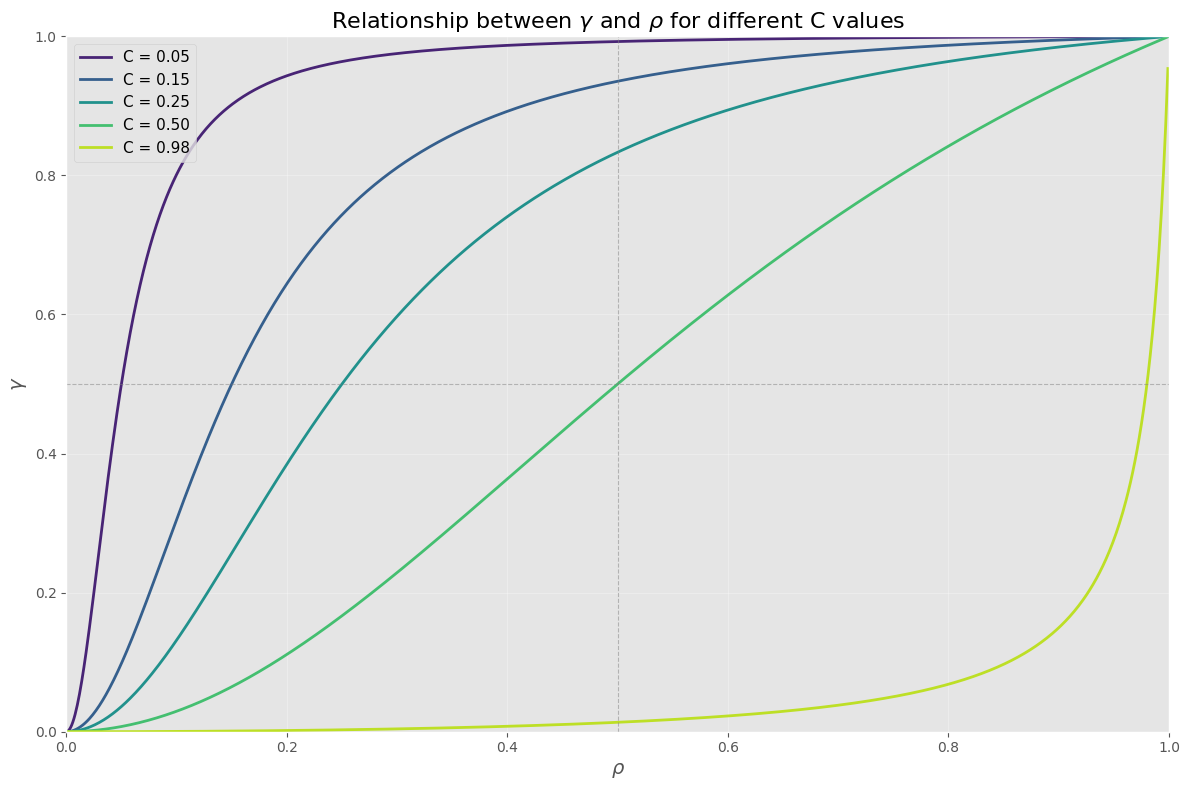

In [57]:
plot_multiple_C_values([0.05, 0.15, 0.25, 0.5, 0.98])

In [58]:
# From the above, let's take the C=0.25 curve and find rho at different levels of gamma. First, what are reasonable values of gamma that we can test? Any value is fine.

In [59]:
C = 0.25
list_gamma = [0.05, 0.25, 0.5, 0.75, 0.95]
list_rho = [solve_C_equation(C, gamma=x) for x in list_gamma]

In [60]:
print(list_rho)

[np.float64(0.05913123959890826), np.float64(0.14744195615489714), np.float64(0.25), np.float64(0.4082482904638631), np.float64(0.7475450015964019)]


In [61]:
# Next we have to get the value of rho we put in the code, which is given by the formula: rho=np.sqrt(0.5*F1*float(noise_level[6:])**2)

In [62]:
# Need to run these experiments! Let's just run the TCTC transformer model.

# We keep T_max to 5000
T_max = 5000


In [63]:
# Let's vary N1, F1, T1 to get the desired values of gamma.

list_N1 = [5,5,10,15,19]
list_F1 = [5,25,25,25,25]
list_T1 = [7,7,7,7,7] # This parameter will be the n_rolling
T1 = 7

def causal_mask(b, h, q_idx, kv_idx):
    return q_idx >= kv_idx

def build_attention_mask(mask_fn, seq_len, device="cpu"):
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device)
    h = torch.zeros(1, device=device)
    mask_bool = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])  # (seq_len, seq_len)
    return mask_bool

mask = causal_mask
mask = build_attention_mask(mask, T1, device=device)
def custom_mask_mod(b, h, q_idx, kv_idx):
    return mask[q_idx, kv_idx]

In [64]:
for i in range(5):
    print(list_F1[i]*list_N1[i]*list_T1[i]/3500)

0.05
0.25
0.5
0.75
0.95


In [65]:
#rho=np.sqrt(0.5*F1*float(noise_level[6:])**2)

list_rho_per_feature = []

for i in range(5):
    list_rho_per_feature.append(list_rho[i]/np.sqrt(0.5*list_F1[i]))

In [66]:
print(list_rho_per_feature)

[np.float64(0.03739787960033828), np.float64(0.04170288281141495), np.float64(0.07071067811865475), np.float64(0.11547005383792516), np.float64(0.21143765594836972)]


In [67]:
dic_data2 = {}

for i in range(5):
    name = "gamma" + str(list_gamma[i])
    dic_data2[name] = generate_synthetic_datasets(num_time_steps=T_max, num_time_series=list_N1[i], num_features=list_F1[i],
                                                  low_corr=list_rho_per_feature[i], high_corr=list_rho_per_feature[i])
    

In [68]:
dic_data2.keys()

dict_keys(['gamma0.05', 'gamma0.25', 'gamma0.5', 'gamma0.75', 'gamma0.95'])

In [69]:
dic_data2['gamma0.05'].keys()

dict_keys(['d_lin', 'd_cond', 'd_shift', 'd_cs', 'd_cs_shift', 'd_all'])

In [70]:
def vary_gamma_all_correl_effets():

    # Storage
    records_train = []
    records_test  = []

    gamma_level_list = list(dic_data2.keys())
    #for gamma_level in dic_data2.keys():
    for i in range(5):
        gamma_level = gamma_level_list[i]   
        for effect in ['d_lin', 'd_cond', 'd_shift', 'd_cs', 'd_cs_shift', 'd_all']:                   
            print(f"Running → {gamma_level} | {effect}")

            z = dic_data2[gamma_level][effect]
            z.get_dataloader(n_rolling=T1, roll_y=True)
            
            lr=0.001/2
            roll_y=True
            
            # epochs = 20
            # if gamma_level in ['correl0.01', 'correl0.03']:
            #     epochs = 40

            # # Model
            # if gamma_level == 'correl0.01':
            #     z.get_dataloader(n_rolling=T1)
            #     roll_y=False
            #     epochs = 60
            #     lr=0.0001

            epochs = 40
            
            model = models.CustomBiDimensionalTransformer(list_N1[i], list_F1[i], T1, mask=mask, layers='TCTC',
                                                dropout=0.05, d_model=128, dim_feedforward=128*4,
                                                                        roll_y=roll_y).to(device)
            
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            wrapper = torch_benchmarks.TorchWrapper(model, optimizer=optimizer, device=device)

            # Train
            wrapper.fit(z.train, test=z.test, epochs=epochs, plot=False)

            # Compare
            comp = benchmark_comparison.Comparator(models=[wrapper], model_names=["model1"])

            corr_train = comp.correl(z, mode="train", return_values=True)
            corr_test  = comp.correl(z, mode="test",  return_values=True)

            train_corr = corr_train.loc["model1", "optimal"]
            test_corr  = corr_test.loc["model1", "optimal"]

            # Save results
            records_train.append({
                "gamma_level": gamma_level,
                "effect": effect,
                "train_corr_optimal": train_corr
            })
            records_test.append({
                "gamma_level": gamma_level,
                "effect": effect,
                "test_corr_optimal": test_corr
            })

    # ————————————————————————————————————————
    # 3. Convert to nice DataFrames
    # ————————————————————————————————————————
    df_train = pd.DataFrame(records_train)
    df_test  = pd.DataFrame(records_test)

    # Pivot: rows = noise level, columns = effect type
    train_pivot = df_train.pivot(index="gamma_level", columns="effect", values="train_corr_optimal")
    test_pivot  = df_test.pivot(index="gamma_level", columns="effect", values="test_corr_optimal")    

    # Sort columns in logical order
    col_order = ["d_lin", "d_cond", "d_shift", "d_cs", "d_cs_shift", "d_all"]
    train_model = train_pivot[col_order]
    test_model  = test_pivot[col_order]

    return train_model, test_model

In [86]:
vary_gamma_train_table, vary_gamma_test_table = vary_gamma_all_correl_effets()

Running → gamma0.05 | d_lin


100%|██████████| 40/40 [00:36<00:00,  1.11it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → gamma0.05 | d_cond


100%|██████████| 40/40 [00:35<00:00,  1.12it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → gamma0.05 | d_shift


...

100%|██████████| 40/40 [02:07<00:00,  3.19s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → gamma0.95 | d_cs_shift


100%|██████████| 40/40 [02:08<00:00,  3.20s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → gamma0.95 | d_all


100%|██████████| 40/40 [02:07<00:00,  3.20s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [87]:
display(vary_gamma_train_table.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

effect,d_lin,d_cond,d_shift,d_cs,d_cs_shift,d_all
gamma_level,,,,,,
gamma0.05,0.060,0.074,0.067,0.050,0.063,0.066
gamma0.25,0.155,0.151,0.145,0.148,0.124,0.148
gamma0.5,0.255,0.261,0.278,0.271,0.239,0.276
gamma0.75,0.485,0.411,0.469,0.474,0.462,0.457
gamma0.95,0.807,0.662,0.784,0.806,0.807,0.766


In [88]:
display(vary_gamma_test_table.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

effect,d_lin,d_cond,d_shift,d_cs,d_cs_shift,d_all
gamma_level,,,,,,
gamma0.05,0.088,0.057,0.062,0.092,0.055,0.101
gamma0.25,0.211,0.128,0.151,0.222,0.032,0.135
gamma0.5,0.316,0.236,0.299,0.333,0.099,0.273
gamma0.75,0.500,0.356,0.486,0.521,0.401,0.464
gamma0.95,0.820,0.583,0.795,0.819,0.808,0.770


In [90]:
# So what do these results mean ? Does this mean that we are assuming some structure in the setup of high gamma and we greatly outperform the theo corr?

# Let's try the same experiements with another model

In [92]:
# Let's try next the 2d MLP

In [108]:
def vary_gamma_all_correl_effets_model2():

    # Storage
    records_train = []
    records_test  = []

    gamma_level_list = list(dic_data2.keys())
    #for gamma_level in dic_data2.keys():
    for i in range(5):
        gamma_level = gamma_level_list[i]   
        for effect in ['d_lin', 'd_cond', 'd_shift', 'd_cs', 'd_cs_shift', 'd_all']:                   
            print(f"Running → {gamma_level} | {effect}")

            z = dic_data2[gamma_level][effect]
            z.get_dataloader(n_rolling=T1)
            
            lr=0.001/2
            
            # epochs = 20
            # if gamma_level in ['correl0.01', 'correl0.03']:
            #     epochs = 40

            # # Model
            # if gamma_level == 'correl0.01':
            #     z.get_dataloader(n_rolling=T1)
            #     roll_y=False
            #     epochs = 60
            #     lr=0.0001

            epochs = 40
            
            # model = models.CustomBiDimensionalTransformer(list_N1[i], list_F1[i], T1, mask=mask, layers='TCTC',
            #                                     dropout=0.05, d_model=128, dim_feedforward=128*4,
            #                                                             roll_y=roll_y).to(device)

            model = BiDimensionalMLP(list_N1[i], list_F1[i], T1, dropout=0.2).to(device)
            
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            wrapper = torch_benchmarks.TorchWrapper(model, optimizer=optimizer, device=device)

            # Train
            wrapper.fit(z.train, test=z.test, epochs=epochs, plot=False)

            # Compare
            comp = benchmark_comparison.Comparator(models=[wrapper], model_names=["model1"])

            corr_train = comp.correl(z, mode="train", return_values=True)
            corr_test  = comp.correl(z, mode="test",  return_values=True)

            train_corr = corr_train.loc["model1", "optimal"]
            test_corr  = corr_test.loc["model1", "optimal"]

            # Save results
            records_train.append({
                "gamma_level": gamma_level,
                "effect": effect,
                "train_corr_optimal": train_corr
            })
            records_test.append({
                "gamma_level": gamma_level,
                "effect": effect,
                "test_corr_optimal": test_corr
            })

    # ————————————————————————————————————————
    # 3. Convert to nice DataFrames
    # ————————————————————————————————————————
    df_train = pd.DataFrame(records_train)
    df_test  = pd.DataFrame(records_test)

    # Pivot: rows = noise level, columns = effect type
    train_pivot = df_train.pivot(index="gamma_level", columns="effect", values="train_corr_optimal")
    test_pivot  = df_test.pivot(index="gamma_level", columns="effect", values="test_corr_optimal")    

    # Sort columns in logical order
    col_order = ["d_lin", "d_cond", "d_shift", "d_cs", "d_cs_shift", "d_all"]
    train_model = train_pivot[col_order]
    test_model  = test_pivot[col_order]

    return train_model, test_model

In [109]:
vary_gamma_train_table_mlp, vary_gamma_test_table_mlp = vary_gamma_all_correl_effets_model2()

Running → gamma0.05 | d_lin


100%|██████████| 40/40 [00:10<00:00,  3.79it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → gamma0.05 | d_cond


100%|██████████| 40/40 [00:09<00:00,  4.33it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → gamma0.05 | d_shift


...

100%|██████████| 40/40 [00:11<00:00,  3.33it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → gamma0.95 | d_cs_shift


100%|██████████| 40/40 [00:11<00:00,  3.39it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running → gamma0.95 | d_all


100%|██████████| 40/40 [00:11<00:00,  3.40it/s]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [110]:
display(vary_gamma_train_table_mlp.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

effect,d_lin,d_cond,d_shift,d_cs,d_cs_shift,d_all
gamma_level,,,,,,
gamma0.05,0.052,0.061,0.060,0.056,0.045,0.051
gamma0.25,0.144,0.131,0.145,0.148,0.135,0.139
gamma0.5,0.244,0.238,0.243,0.245,0.246,0.241
gamma0.75,0.383,0.363,0.381,0.377,0.384,0.369
gamma0.95,0.600,0.574,0.604,0.602,0.611,0.597


In [111]:
display(vary_gamma_test_table_mlp.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

effect,d_lin,d_cond,d_shift,d_cs,d_cs_shift,d_all
gamma_level,,,,,,
gamma0.05,0.071,0.017,0.104,0.080,0.052,0.055
gamma0.25,0.190,0.017,0.197,0.163,0.175,0.123
gamma0.5,0.336,-0.004,0.350,0.335,0.346,0.227
gamma0.75,0.563,0.010,0.540,0.548,0.548,0.423
gamma0.95,0.778,-0.005,0.789,0.782,0.791,0.691


In [45]:
# Ok there is something we don't understand then... let's try the Lasso model and make sure that the theo correl it gives is at the correct value.

In [71]:
def vary_gamma_all_correl_effets_lasso():

    # Storage
    records_train = []
    records_test  = []

    gamma_level_list = list(dic_data2.keys())
    #for gamma_level in dic_data2.keys():
    for i in range(5):
        gamma_level = gamma_level_list[i]   
        for effect in ['d_lin', 'd_cond', 'd_shift', 'd_cs', 'd_cs_shift', 'd_all']:                   
            print(f"Running → {gamma_level} | {effect}")

            z = dic_data2[gamma_level][effect]
            z.get_dataloader(n_rolling=T1)

            lasso_full = ml_benchmarks.CustomBenchmarkRolling(LassoCV(alphas=np.linspace(start=1e-4, stop=1e-2, num=30), 
                                                                    verbose=False, max_iter=2000, selection='random', n_jobs=5, cv=3))
            lasso_full.fit(z.train)
            

            comp = benchmark_comparison.Comparator(models=[lasso_full], model_names=['lasso_full'])
            
            corr_train = comp.correl(z, mode="train", return_values=True)
            corr_test  = comp.correl(z, mode="test",  return_values=True)

            train_corr = corr_train.loc["lasso_full", "optimal"]
            test_corr  = corr_test.loc["lasso_full", "optimal"]

            # Save results
            records_train.append({
                "gamma_level": gamma_level,
                "effect": effect,
                "train_corr_optimal": train_corr
            })
            records_test.append({
                "gamma_level": gamma_level,
                "effect": effect,
                "test_corr_optimal": test_corr
            })

    # ————————————————————————————————————————
    # 3. Convert to nice DataFrames
    # ————————————————————————————————————————
    df_train = pd.DataFrame(records_train)
    df_test  = pd.DataFrame(records_test)

    # Pivot: rows = noise level, columns = effect type
    train_pivot = df_train.pivot(index="gamma_level", columns="effect", values="train_corr_optimal")
    test_pivot  = df_test.pivot(index="gamma_level", columns="effect", values="test_corr_optimal")    

    # Sort columns in logical order
    col_order = ["d_lin", "d_cond", "d_shift", "d_cs", "d_cs_shift", "d_all"]
    train_model = train_pivot[col_order]
    test_model  = test_pivot[col_order]

    return train_model, test_model

In [72]:
vary_gamma_train_table_lasso, vary_gamma_test_table_lasso = vary_gamma_all_correl_effets_lasso()

Running → gamma0.05 | d_lin
Running → gamma0.05 | d_cond
Running → gamma0.05 | d_shift
Running → gamma0.05 | d_cs
Running → gamma0.05 | d_cs_shift
Running → gamma0.05 | d_all
Running → gamma0.25 | d_lin
Running → gamma0.25 | d_cond
Running → gamma0.25 | d_shift
Running → gamma0.25 | d_cs
Running → gamma0.25 | d_cs_shift
Running → gamma0.25 | d_all
Running → gamma0.5 | d_lin


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.543e+00, tolerance: 2.351e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.602e+00, tolerance: 2.351e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features o

Running → gamma0.5 | d_cond


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.124e+00, tolerance: 2.306e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.220e+01, tolerance: 2.307e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features o

Running → gamma0.5 | d_shift


...

Running → gamma0.5 | d_cs_shift


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.429e+00, tolerance: 2.340e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.370e+00, tolerance: 2.331e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features o

Running → gamma0.5 | d_all


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.257e+00, tolerance: 2.351e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.583e+00, tolerance: 2.356e+00
  model = cd_fast.enet_coordinate_descent_gram(


Running → gamma0.75 | d_lin
Running → gamma0.75 | d_cond
Running → gamma0.75 | d_shift
Running → gamma0.75 | d_cs
Running → gamma0.75 | d_cs_shift
Running → gamma0.75 | d_all
Running → gamma0.95 | d_lin
Running → gamma0.95 | d_cond
Running → gamma0.95 | d_shift
Running → gamma0.95 | d_cs
Running → gamma0.95 | d_cs_shift
Running → gamma0.95 | d_all


In [73]:
display(vary_gamma_train_table_lasso.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

effect,d_lin,d_cond,d_shift,d_cs,d_cs_shift,d_all
gamma_level,,,,,,
gamma0.05,0.036,0.005,0.039,0.066,0.146,0.113
gamma0.25,0.092,0.017,0.137,0.127,0.083,0.057
gamma0.5,0.077,0.030,0.122,0.077,0.108,0.090
gamma0.75,0.101,0.031,0.115,0.108,0.130,0.093
gamma0.95,0.186,0.032,0.178,0.181,0.170,0.180


In [74]:
display(vary_gamma_test_table_lasso.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

effect,d_lin,d_cond,d_shift,d_cs,d_cs_shift,d_all
gamma_level,,,,,,
gamma0.05,0.043,-0.009,0.039,0.045,0.167,0.138
gamma0.25,0.097,-0.007,0.121,0.092,0.065,0.050
gamma0.5,0.048,-0.002,0.085,0.049,0.078,0.072
gamma0.75,0.072,-0.000,0.103,0.088,0.112,0.052
gamma0.95,0.169,-0.004,0.160,0.162,0.155,0.163


In [75]:
def vary_gamma_all_correl_effets_ols():

    # Storage
    records_train = []
    records_test  = []

    gamma_level_list = list(dic_data2.keys())
    #for gamma_level in dic_data2.keys():
    for i in range(5):
        gamma_level = gamma_level_list[i]   
        for effect in ['d_lin', 'd_cond', 'd_shift', 'd_cs', 'd_cs_shift', 'd_all']:                   
            print(f"Running → {gamma_level} | {effect}")

            z = dic_data2[gamma_level][effect]
            z.get_dataloader(n_rolling=T1)

            lasso_full = ml_benchmarks.CustomBenchmarkRolling(LinearRegression())
            lasso_full.fit(z.train)
            

            comp = benchmark_comparison.Comparator(models=[lasso_full], model_names=['lasso_full'])
            
            corr_train = comp.correl(z, mode="train", return_values=True)
            corr_test  = comp.correl(z, mode="test",  return_values=True)

            train_corr = corr_train.loc["lasso_full", "optimal"]
            test_corr  = corr_test.loc["lasso_full", "optimal"]

            # Save results
            records_train.append({
                "gamma_level": gamma_level,
                "effect": effect,
                "train_corr_optimal": train_corr
            })
            records_test.append({
                "gamma_level": gamma_level,
                "effect": effect,
                "test_corr_optimal": test_corr
            })

    # ————————————————————————————————————————
    # 3. Convert to nice DataFrames
    # ————————————————————————————————————————
    df_train = pd.DataFrame(records_train)
    df_test  = pd.DataFrame(records_test)

    # Pivot: rows = noise level, columns = effect type
    train_pivot = df_train.pivot(index="gamma_level", columns="effect", values="train_corr_optimal")
    test_pivot  = df_test.pivot(index="gamma_level", columns="effect", values="test_corr_optimal")    

    # Sort columns in logical order
    col_order = ["d_lin", "d_cond", "d_shift", "d_cs", "d_cs_shift", "d_all"]
    train_model = train_pivot[col_order]
    test_model  = test_pivot[col_order]

    return train_model, test_model

In [76]:
vary_gamma_train_table_ols, vary_gamma_test_table_ols = vary_gamma_all_correl_effets_lasso()

Running → gamma0.05 | d_lin
Running → gamma0.05 | d_cond
Running → gamma0.05 | d_shift
Running → gamma0.05 | d_cs
Running → gamma0.05 | d_cs_shift
Running → gamma0.05 | d_all
Running → gamma0.25 | d_lin
Running → gamma0.25 | d_cond
Running → gamma0.25 | d_shift
Running → gamma0.25 | d_cs
Running → gamma0.25 | d_cs_shift
Running → gamma0.25 | d_all
Running → gamma0.5 | d_lin


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.863e+00, tolerance: 2.351e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.469e+00, tolerance: 2.351e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features o

Running → gamma0.5 | d_cond


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.391e+00, tolerance: 2.306e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.907e+00, tolerance: 2.303e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features o

Running → gamma0.5 | d_shift


...

Running → gamma0.5 | d_cs_shift


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.178e+00, tolerance: 2.340e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.257e+00, tolerance: 2.331e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features o

Running → gamma0.5 | d_all


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.156e+00, tolerance: 2.356e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.367e+00, tolerance: 2.351e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features o

Running → gamma0.75 | d_lin
Running → gamma0.75 | d_cond
Running → gamma0.75 | d_shift
Running → gamma0.75 | d_cs
Running → gamma0.75 | d_cs_shift
Running → gamma0.75 | d_all
Running → gamma0.95 | d_lin
Running → gamma0.95 | d_cond
Running → gamma0.95 | d_shift
Running → gamma0.95 | d_cs
Running → gamma0.95 | d_cs_shift
Running → gamma0.95 | d_all


In [77]:
display(vary_gamma_train_table_ols.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

effect,d_lin,d_cond,d_shift,d_cs,d_cs_shift,d_all
gamma_level,,,,,,
gamma0.05,0.036,0.005,0.039,0.066,0.146,0.113
gamma0.25,0.092,0.017,0.137,0.127,0.083,0.057
gamma0.5,0.077,0.030,0.122,0.077,0.108,0.090
gamma0.75,0.101,0.031,0.115,0.108,0.130,0.093
gamma0.95,0.186,0.032,0.178,0.181,0.170,0.180


In [78]:
display(vary_gamma_test_table_ols.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

effect,d_lin,d_cond,d_shift,d_cs,d_cs_shift,d_all
gamma_level,,,,,,
gamma0.05,0.043,-0.009,0.039,0.045,0.167,0.138
gamma0.25,0.097,-0.007,0.121,0.092,0.065,0.050
gamma0.5,0.048,-0.002,0.085,0.049,0.078,0.072
gamma0.75,0.072,-0.000,0.103,0.088,0.112,0.052
gamma0.95,0.169,-0.004,0.160,0.162,0.155,0.163


## Plots at fixed rho, gamma but with varying data dimensions

In [42]:
# Another test we can do is do see how different models perform when rho, gamma are fixed but when the dimensions N,T,F change.

In [43]:
# Here let's the original data dimensions that we were using.

In [44]:
# Global parameters
T_max = 5000
N1 = 10
F1 = 20
T1 = 5 # This parameter will be the n_rolling

print(T_max, N1, F1, T1)

5000 10 20 5


In [45]:
# Here we have gamma equal to:
print(N1*F1*T1/(0.7*T_max))

# The product of features is equal to:
print(N1*F1*T1)

0.2857142857142857
1000


In [ ]:
# Let's do a dic with some dimensions we want to test, using the ordering N, F, T

dic_dimensions = {#"baseline": [10, 20, 5],
                  "long_T": [10, 10, 50],
                  "vlong_T": [2, 5, 100],
                  #"long_F": [10, 50, 10],
                 #"vlong_F": [2, 100, 5],
                  #"long_N": [50, 10, 10],
                 #"vlong_N": [100, 2, 5]
                  }

In [47]:
# In the baseline, when the rho per feature is 10%, the global rho is then:
global_rho_baseline = 0.1*np.sqrt(0.5*20)
print(global_rho_baseline)

0.316227766016838


In [48]:
#rho=np.sqrt(0.5*F1*float(noise_level[6:])**2)

In [ ]:
dic_data3 = {}

global_rho_baseline = 0.1*np.sqrt(0.5*20)

for key in dic_dimensions.keys():
    dim_list = dic_dimensions[key]
    Ni,Fi,Ti = dim_list[0], dim_list[1], dim_list[2]
    rho_feature_i = global_rho_baseline/np.sqrt(0.5*Fi) 
    dic_data3[key] = generate_synthetic_datasets(num_time_steps=T_max, num_time_series=Ni, num_features=Fi,
                                                  low_corr=rho_feature_i, high_corr=rho_feature_i)

In [50]:
def vary_dimensions_all_correl_effets():

    # Storage
    records_train = []
    records_test  = []

    for dim in dic_data3.keys():
        #for effect in ['d_lin', 'd_cond', 'd_shift', 'd_cs', 'd_cs_shift', 'd_all']:
        for effect in ['d_shift']:
            Ni, Fi, Ti = dic_dimensions[dim][0], dic_dimensions[dim][1], dic_dimensions[dim][2]                   
            print(f"Running → {dim} | {effect}")

            z = dic_data3[dim][effect]
            z.get_dataloader(n_rolling=Ti, roll_y=True)
            
            lr=0.001/2
            roll_y=True
            
            # epochs = 20
            # if dim in ['correl0.01', 'correl0.03']:
            #     epochs = 40

            # # Model
            # if dim == 'correl0.01':
            #     z.get_dataloader(n_rolling=T1)
            #     roll_y=False
            #     epochs = 60
            #     lr=0.0001

            epochs = 40

            mask = causal_mask
            mask = build_attention_mask(mask, Ti, device=device)
            
            model = models.CustomBiDimensionalTransformer(Ni, Fi, Ti, mask=mask, layers='TCTC',
                                                dropout=0.05, d_model=128, dim_feedforward=128*4,
                                                                        roll_y=roll_y).to(device)
            
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            wrapper = torch_benchmarks.TorchWrapper(model, optimizer=optimizer, device=device)

            # Train
            wrapper.fit(z.train, test=z.test, epochs=epochs, plot=False)

            # Compare
            comp = benchmark_comparison.Comparator(models=[wrapper], model_names=["model1"])

            corr_train = comp.correl(z, mode="train", return_values=True)
            corr_test  = comp.correl(z, mode="test",  return_values=True)

            train_corr = corr_train.loc["model1", "optimal"]
            test_corr  = corr_test.loc["model1", "optimal"]

            # Save results
            records_train.append({
                "dim": dim,
                "effect": effect,
                "train_corr_optimal": train_corr
            })
            records_test.append({
                "dim": dim,
                "effect": effect,
                "test_corr_optimal": test_corr
            })

    # ————————————————————————————————————————
    # 3. Convert to nice DataFrames
    # ————————————————————————————————————————
    df_train = pd.DataFrame(records_train)
    df_test  = pd.DataFrame(records_test)

    # Pivot: rows = noise level, columns = effect type
    train_pivot = df_train.pivot(index="dim", columns="effect", values="train_corr_optimal")
    test_pivot  = df_test.pivot(index="dim", columns="effect", values="test_corr_optimal")    

    # Sort columns in logical order
    col_order = ["d_lin", "d_cond", "d_shift", "d_cs", "d_cs_shift", "d_all"]
    train_model = train_pivot[col_order]
    test_model  = test_pivot[col_order]

    return train_model, test_model

In [51]:
vary_dims_train_table, vary_dims_test_table = vary_dimensions_all_correl_effets()

Running → long_T | d_shift


  5%|▌         | 2/40 [01:50<35:04, 55.37s/it]


KeyboardInterrupt: 

In [35]:
display(vary_dims_train_table.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

effect,d_lin,d_cond,d_shift,d_cs,d_cs_shift,d_all
dim,,,,,,
baseline,0.366,0.330,0.366,0.369,0.370,0.346


In [36]:
display(vary_dims_test_table.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

effect,d_lin,d_cond,d_shift,d_cs,d_cs_shift,d_all
dim,,,,,,
baseline,0.408,0.302,0.355,0.422,0.368,0.341


## Rerun of some experiments

In [29]:
# Let's rerun some the experiments above that did not make any sense.

In [30]:
# Let's first rerun the models on all the effects.

In [31]:
dic_models, dic_models_rollfalse = get_models()

all_effects_train_5, all_effects_test_5 = run_models_all_effect("correl0.05", dic_models, dic_models_rollfalse)

Running → correl0.05 | MLP_global


100%|██████████| 20/20 [00:03<00:00,  5.65it/s]


Running → correl0.05 | MLP_2D


100%|██████████| 20/20 [00:05<00:00,  3.83it/s]


Running → correl0.05 | trans_1D_T4


100%|██████████| 20/20 [00:08<00:00,  2.28it/s]


Running → correl0.05 | trans_2D_TCTC


100%|██████████| 20/20 [00:24<00:00,  1.24s/it]


Running → correl0.05 | trans_2D_TCTCTCTC


100%|██████████| 20/20 [00:45<00:00,  2.26s/it]
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [34]:
display(all_effects_train_5.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,true,optimal,linear,conditional,shift,cs,cs_shift,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC
optimal,0.153,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
linear,0.069,0.453,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
conditional,0.069,0.452,0.001,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.064,0.452,0.005,0.000,nan,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.071,0.452,0.009,0.009,0.008,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.072,0.453,0.008,0.007,0.010,0.001,nan,nan,nan,nan,nan,nan,nan
lasso_full,0.110,0.047,0.010,-0.002,0.034,0.050,0.015,nan,nan,nan,nan,nan,nan
boosting,0.260,0.036,0.005,0.008,0.019,0.029,0.021,0.300,nan,nan,nan,nan,nan
MLP_global,0.984,0.159,0.073,0.067,0.071,0.074,0.076,0.113,0.256,nan,nan,nan,nan
MLP_2D,0.940,0.154,0.070,0.065,0.065,0.072,0.076,0.109,0.250,0.927,nan,nan,nan


In [35]:
display(all_effects_test_5.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,true,optimal,linear,conditional,shift,cs,cs_shift,lasso_full,boosting,MLP_global,MLP_2D,trans_1D_T4,trans_2D_TCTC
optimal,0.149,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
linear,0.067,0.452,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
conditional,0.072,0.460,0.006,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.071,0.456,0.007,0.017,nan,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.054,0.454,0.008,0.010,0.009,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.074,0.450,-0.001,0.014,0.008,0.003,nan,nan,nan,nan,nan,nan,nan
lasso_full,0.016,0.024,0.007,0.001,0.014,0.040,-0.007,nan,nan,nan,nan,nan,nan
boosting,0.002,0.016,0.008,-0.008,0.006,0.019,0.010,0.133,nan,nan,nan,nan,nan
MLP_global,0.022,0.171,0.098,0.014,0.088,0.104,0.082,0.080,0.033,nan,nan,nan,nan
MLP_2D,0.006,0.107,0.053,-0.001,0.046,0.078,0.067,0.061,0.006,0.347,nan,nan,nan


In [36]:
# So here we see that the trans_2D_TCTC performs well on all the effects including the cs_shift, not so much at 5% correl...

Running → correl0.05 | trans_2D_TCTC


100%|██████████| 20/20 [00:28<00:00,  1.42s/it]


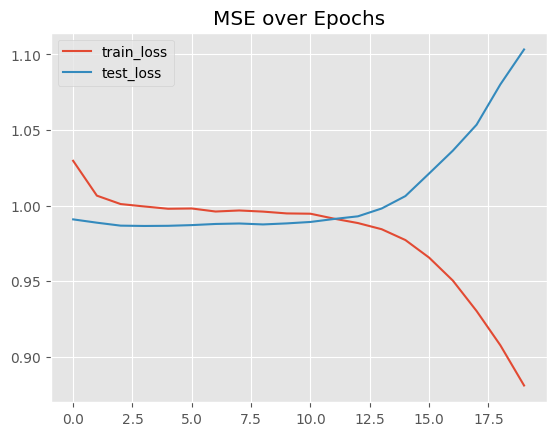

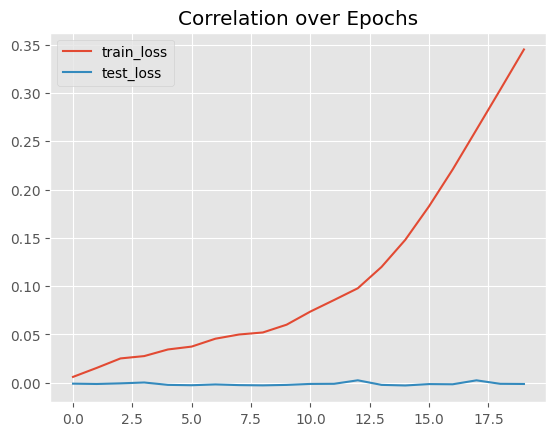

/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


0.08176604627617444 0.018516542004985276


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


,true,optimal,cs_shift
optimal,0.154,nan,nan
cs_shift,0.154,1.000,nan
model1,0.410,0.084,0.084


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


,true,optimal,cs_shift
optimal,0.157,nan,nan
cs_shift,0.157,1.000,nan
model1,0.004,0.016,0.016


In [44]:
z = dic_data["correl0.05"]["d_cs_shift"]
z.get_dataloader(n_rolling=T1)

dic_models, dic_models_rollfalse = get_models()

noise_level = "correl0.05"
effect1 = "d_cs_shift"

for model_key in ['trans_2D_TCTC']:                   
        print(f"Running → {noise_level} | {model_key}")

        z = dic_data[noise_level][effect1]
        if model_key in ["trans_1D_T4", "trans_2D_TCTC", "trans_2D_TCTCTCTC"]:
            z.get_dataloader(n_rolling=T1, roll_y=True)
        else:
            z.get_dataloader(n_rolling=T1)

        if model_key in ["trans_2D_TCTC", "trans_2D_TCTCTCTC"]:
            lr=0.001/2
        else:
            lr=0.001

        epochs = 20
        if noise_level in ['correl0.01', 'correl0.03']:
            epochs = 40

        model = dic_models[model_key]

        # Model
        if noise_level == 'correl0.01' and model_key in ["trans_2D_TCTC", "trans_2D_TCTCTCTC"]:
            z.get_dataloader(n_rolling=T1)
            model = dic_models_rollfalse[model_key]
            epochs = 60
            lr=0.0001

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        wrapper = torch_benchmarks.TorchWrapper(model, optimizer=optimizer, device=device)

        
        # Train
    
        wrapper.fit(z.train, test=z.test, epochs=epochs, plot=True)

        # Compare
        comp = benchmark_comparison.Comparator(models=[wrapper], model_names=["model1"])


        out_train = comp.correl(z, mode="train", return_values=True).loc["model1", "optimal"]
        out_test = comp.correl(z, mode="test", return_values=True).loc["model1", "optimal"]

        print(out_train, out_test)

        display(comp.correl(z, mode='train'))
        display(comp.correl(z, mode='test'))
    